In [1]:
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 100)

import warnings
warnings.filterwarnings('ignore')

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/phems-hackathon-early-sepsis-prediction/SepsisLabel_sample_submission.csv
/kaggle/input/phems-hackathon-early-sepsis-prediction/training_data/drugsexposure_train.csv
/kaggle/input/phems-hackathon-early-sepsis-prediction/training_data/observation_train.csv
/kaggle/input/phems-hackathon-early-sepsis-prediction/training_data/devices_train.csv
/kaggle/input/phems-hackathon-early-sepsis-prediction/training_data/measurement_lab_train.csv
/kaggle/input/phems-hackathon-early-sepsis-prediction/training_data/proceduresoccurrences_train.csv
/kaggle/input/phems-hackathon-early-sepsis-prediction/training_data/person_demographics_episode_train.csv
/kaggle/input/phems-hackathon-early-sepsis-prediction/training_data/SepsisLabel_train.csv
/kaggle/input/phems-hackathon-early-sepsis-prediction/training_data/measurement_observation_train.csv
/kaggle/input/phems-hackathon-early-sepsis-prediction/training_data/measurement_meds_train.csv
/kaggle/input/phems-hackathon-early-sepsis-prediction/tes

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [3]:
data_dir = '/kaggle/input/phems-hackathon-early-sepsis-prediction/'

In [4]:
train_path = f'{data_dir}/training_data'
test_path = f'{data_dir}/testing_data'

In [5]:
train_labels = pd.read_csv(f"{train_path}/SepsisLabel_train.csv")

In [6]:
test_set = pd.read_csv(f"{test_path}/SepsisLabel_test.csv")

# Data Preprocessing pt. 1

## Merging data

In [7]:
def get_measurements(path):
    mode='test'
    if 'train' in path:
        mode = 'train'
    measurem_lab = pd.read_csv(f"{path}/measurement_lab_{mode}.csv")
    measurem_meds = pd.read_csv(f"{path}/measurement_meds_{mode}.csv")
    measurem_obs = pd.read_csv(f"{path}/measurement_observation_{mode}.csv")
    measurements = measurem_lab.merge(measurem_meds, how='outer').merge(measurem_obs, how='outer')
    return measurements

In [8]:
def get_drug(prev_data, path):
    print("==== drug ====")
    mode='test'
    if 'train' in path:
        mode = 'train'
    drug = pd.read_csv(f"{path}/drugsexposure_{mode}.csv")
    drug = drug.rename(columns={'drug_datetime_hourly': 'measurement_datetime'})
    print("old shape: ", prev_data.shape)
    prev_data = prev_data.merge(drug, how='outer')
    print("new shape: ", prev_data.shape)
    return prev_data

In [9]:
def get_procedures(prev_data, path):
    print("==== procedures ====")
    mode='test'
    if 'train' in path:
        mode = 'train'
    data = pd.read_csv(f"{path}/proceduresoccurrences_{mode}.csv")
    data = data.rename(columns={'procedure_datetime_hourly': 'measurement_datetime'})
    print("old shape: ", prev_data.shape)
    prev_data = prev_data.merge(data, how='outer')
    print("new shape: ", prev_data.shape)
    return prev_data

In [10]:
def get_demographics(prev_data, path):
    print("==== demographics ====")
    mode='test'
    if 'train' in path:
        mode = 'train'
    data = pd.read_csv(f"{path}/person_demographics_episode_{mode}.csv")
    data = data[['visit_occurrence_id', 'person_id', 'age_in_months', 'gender']].drop_duplicates()
    print("old shape: ", prev_data.shape)
    prev_data = prev_data.merge(data, how='outer')
    print("new shape: ", prev_data.shape)
    return prev_data

In [11]:
def get_devices(prev_data, path):
    print("==== devices ====")
    mode='test'
    if 'train' in path:
        mode = 'train'
    data = pd.read_csv(f"{path}/devices_{mode}.csv")
    data = data.rename(columns={'device_datetime_hourly': 'measurement_datetime'})
    print("old shape: ", prev_data.shape)
    prev_data = prev_data.merge(data, how='outer')
    print("new shape: ", prev_data.shape)
    return prev_data

In [12]:
def get_observations(prev_data, path):
    print("==== observations ====")
    mode='test'
    if 'train' in path:
        mode = 'train'
    data = pd.read_csv(f"{path}/observation_{mode}.csv")
    data = data.rename(columns={'observation_datetime': 'measurement_datetime', 'valuefilled': 'admission_reason'})
    print("old shape: ", prev_data.shape)
    prev_data = prev_data.merge(data[['visit_occurrence_id', 'person_id', 'measurement_datetime', 'admission_reason']], how='outer')
    print("new shape: ", prev_data.shape)
    return prev_data

In [13]:
data = get_measurements(train_path)

In [14]:
data_test = get_measurements(test_path)

In [15]:
data.head()

,visit_occurrence_id,person_id,measurement_datetime,Base excess in Venous blood by calculation,Base excess in Arterial blood by calculation,Phosphate [Moles/volume] in Serum or Plasma,Potassium [Moles/volume] in Blood,Bilirubin.total [Moles/volume] in Serum or Plasma,Neutrophil Ab [Units/volume] in Serum,Bicarbonate [Moles/volume] in Arterial blood,Hematocrit [Volume Fraction] of Blood,Glucose [Moles/volume] in Serum or Plasma,Calcium [Moles/volume] in Serum or Plasma,Chloride [Moles/volume] in Blood,Sodium [Moles/volume] in Serum or Plasma,C reactive protein [Mass/volume] in Serum or Plasma,Carbon dioxide [Partial pressure] in Venous blood,Oxygen [Partial pressure] in Venous blood,Albumin [Mass/volume] in Serum or Plasma,Bicarbonate [Moles/volume] in Venous blood,Oxygen [Partial pressure] in Arterial blood,Carbon dioxide [Partial pressure] in Arterial blood,Interleukin 6 [Mass/volume] in Body fluid,Magnesium [Moles/volume] in Blood,Prothrombin time (PT),Procalcitonin [Mass/volume] in Serum or Plasma,Lactate [Moles/volume] in Blood,Creatinine [Mass/volume] in Blood,Fibrinogen measurement,Bilirubin measurement,Partial thromboplastin time,activated,Total white blood count,Platelet count,White blood cell count,Blood venous pH,D-dimer level,Blood arterial pH,Hemoglobin [Moles/volume] in Blood,Ionised calcium measurement,Systolic blood pressure,Diastolic blood pressure,Body temperature,Respiratory rate,Heart rate,Measurement of oxygen saturation at periphery,Oxygen/Gas total [Pure volume fraction] Inhaled gas,Left pupil Diameter Auto,Right pupil Diameter Auto,Glasgow coma scale,Capillary refill [Time],Pulse,Arterial pulse pressure,Right pupil Pupillary response,Left pupil Pupillary response
0,933758,523870286,2023-12-06 17:00:00,-2.4,NaN,NaN,3.7,NaN,NaN,NaN,35.1,NaN,NaN,107.0,140.0,NaN,34.9,68.0,NaN,21.6,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,18.3,201.0,NaN,7.41,NaN,NaN,12.3,1.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,933758,523870286,2023-12-06 18:00:00,NaN,NaN,NaN,NaN,NaN,15.2,NaN,NaN,NaN,NaN,NaN,NaN,116.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.91,NaN,47.6,NaN,NaN,NaN,NaN,NaN,0.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,933758,523870286,2023-12-07 08:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.3,208.0,NaN,NaN,NaN,NaN,11.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,933758,523870286,2023-12-07 09:00:00,-1.2,NaN,NaN,3.5,NaN,9.3,NaN,NaN,NaN,NaN,110.0,141.0,75.0,33.3,30.0,NaN,22.4,NaN,NaN,NaN,NaN,NaN,1.25,1.2,48.2,NaN,NaN,NaN,NaN,NaN,1.1,7.44,NaN,NaN,NaN,1.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,933758,523870286,2023-12-07 10:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,104.0,41.0,NaN,33.711113,156.93478,95.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
data = get_drug(data, train_path)
data = get_procedures(data, train_path)
data = get_demographics(data, train_path)
data = get_devices(data, train_path)
data = get_observations(data, train_path)

==== drug ====
old shape:  (324253, 55)
new shape:  (455538, 57)
==== procedures ====
old shape:  (455538, 57)
new shape:  (990251, 58)
==== demographics ====
old shape:  (990251, 58)
new shape:  (990256, 60)
==== devices ====
old shape:  (990256, 60)
new shape:  (1080315, 61)
==== observations ====
old shape:  (1080315, 61)
new shape:  (1081455, 62)


In [17]:
data_test = get_drug(data_test, test_path)
data_test = get_procedures(data_test, test_path)
data_test = get_demographics(data_test, test_path)
data_test = get_devices(data_test, test_path)
data_test = get_observations(data_test, test_path)

==== drug ====
old shape:  (128897, 55)
new shape:  (180906, 57)
==== procedures ====
old shape:  (180906, 57)
new shape:  (389110, 58)
==== demographics ====
old shape:  (389110, 58)
new shape:  (389112, 60)
==== devices ====
old shape:  (389112, 60)
new shape:  (447201, 61)
==== observations ====
old shape:  (447201, 61)
new shape:  (447663, 62)


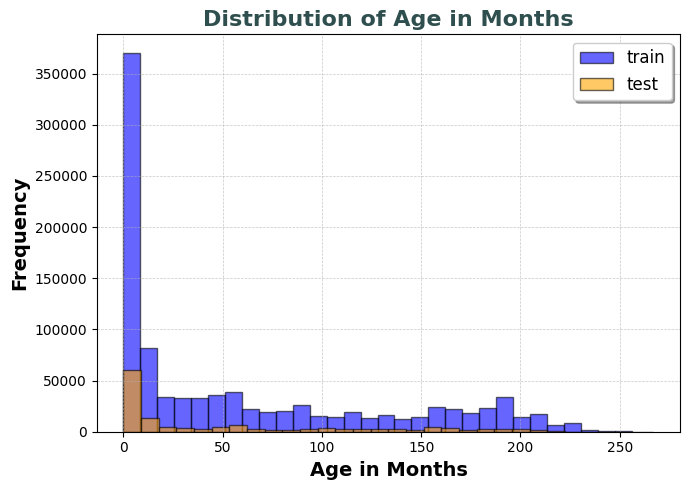

In [18]:
# Create histograms for 'age_in_months'
plt.figure(figsize=(7, 5), dpi=100)

# Histogram for `data['age_in_months']`
plt.hist(data['age_in_months'], bins=30, alpha=0.6, label='train', color='blue', edgecolor='black')

# Histogram for `test_set.merge(data_test, how='left')['age_in_months']`
plt.hist(test_set.merge(data_test, how='left')['age_in_months'], bins=30, alpha=0.6, label='test', color='orange', edgecolor='black')

# Add gridlines for better readability
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Add axis labels
plt.xlabel('Age in Months', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

# Add title
plt.title('Distribution of Age in Months', fontsize=16, fontweight='bold', color='darkslategray')

# Add legend
plt.legend(fontsize=12, loc='upper right', frameon=True, shadow=True)

# Use tight layout for cleaner spacing
plt.tight_layout()

# Show the plot
plt.show()

In [19]:
numerical_cols = ['Base excess in Venous blood by calculation',
       'Base excess in Arterial blood by calculation',
       'Phosphate [Moles/volume] in Serum or Plasma',
       'Potassium [Moles/volume] in Blood',
       'Bilirubin.total [Moles/volume] in Serum or Plasma',
       'Neutrophil Ab [Units/volume] in Serum',
       'Bicarbonate [Moles/volume] in Arterial blood',
       'Hematocrit [Volume Fraction] of Blood',
       'Glucose [Moles/volume] in Serum or Plasma',
       'Calcium [Moles/volume] in Serum or Plasma',
       'Chloride [Moles/volume] in Blood',
       'Sodium [Moles/volume] in Serum or Plasma',
       'C reactive protein [Mass/volume] in Serum or Plasma',
       'Carbon dioxide [Partial pressure] in Venous blood',
       'Oxygen [Partial pressure] in Venous blood',
       'Albumin [Mass/volume] in Serum or Plasma',
       'Bicarbonate [Moles/volume] in Venous blood',
       'Oxygen [Partial pressure] in Arterial blood',
       'Carbon dioxide [Partial pressure] in Arterial blood',
       'Interleukin 6 [Mass/volume] in Body fluid',
       'Magnesium [Moles/volume] in Blood', 'Prothrombin time (PT)',
       'Procalcitonin [Mass/volume] in Serum or Plasma',
       'Lactate [Moles/volume] in Blood', 'Creatinine [Mass/volume] in Blood',
       'Fibrinogen measurement', 'Bilirubin measurement',
       'Partial thromboplastin time', ' activated', 'Total white blood count',
       'Platelet count', 'White blood cell count', 'Blood venous pH',
       'D-dimer level', 'Blood arterial pH',
       'Hemoglobin [Moles/volume] in Blood', 'Ionised calcium measurement',
       'Systolic blood pressure', 'Diastolic blood pressure',
       'Body temperature', 'Respiratory rate', 'Heart rate',
       'Measurement of oxygen saturation at periphery',
       'Oxygen/Gas total [Pure volume fraction] Inhaled gas']

## Removing outliers

In [20]:
def remove_outliers(data, cols):
  # compute 98th percentiles for each numeric column
  percentile_98 = data[numerical_cols].quantile(0.98)
  percentile_98 = percentile_98[~percentile_98.isna()]

  # filter 98% persentile and replace with nan
  for col in numerical_cols:
      if col in percentile_98:
          data[col] = data[col].where(data[col] <= percentile_98[col], np.nan)
  return data

In [21]:
data.shape

(1081455, 62)

In [22]:
data_filtered = remove_outliers(data, numerical_cols)

In [23]:
data_filtered.shape

(1081455, 62)

In [24]:
data_test.shape

(447663, 62)

In [25]:
data_test_filtered = remove_outliers(data_test, numerical_cols)
data_test_filtered.shape

(447663, 62)

In [26]:
data_filtered['id'] = data_filtered['person_id'].astype(str) + '_' + data_filtered['visit_occurrence_id'].astype(str)
data_test_filtered['id'] = data_test_filtered['person_id'].astype(str) + '_' + data_test_filtered['visit_occurrence_id'].astype(str)

## Filling in Nans

In [159]:
# forward filling by (person_id + visit_occurrence_id) with sorted measurement_datetime
def filling_missing_values(data):
  print("old data shape: ", data.shape)
  data = data.sort_values(by=['id', 'measurement_datetime'])
  visits_id = data['id']
  data = data.groupby('id').ffill()
  data['id'] = visits_id

  mode_values = data.groupby('id').agg({
    'age_in_months': lambda x: x.mode()[0],
    'gender': lambda x: x.mode()[0]
  }).reset_index()

  data = data.drop(['age_in_months', 'gender'], axis=1)
  # replace age_in_months and gender nans with mode - in our case it should be the same for every id
  data = data.merge(mode_values, how='left')
  print("new data shape: ", data.shape)
  return data

In [28]:
data_filtered = filling_missing_values(data_filtered)

old data shape:  (1081455, 63)
new data shape:  (1081455, 63)


In [29]:
data_filtered

,visit_occurrence_id,person_id,measurement_datetime,Base excess in Venous blood by calculation,Base excess in Arterial blood by calculation,Phosphate [Moles/volume] in Serum or Plasma,Potassium [Moles/volume] in Blood,Bilirubin.total [Moles/volume] in Serum or Plasma,Neutrophil Ab [Units/volume] in Serum,Bicarbonate [Moles/volume] in Arterial blood,Hematocrit [Volume Fraction] of Blood,Glucose [Moles/volume] in Serum or Plasma,Calcium [Moles/volume] in Serum or Plasma,Chloride [Moles/volume] in Blood,Sodium [Moles/volume] in Serum or Plasma,C reactive protein [Mass/volume] in Serum or Plasma,Carbon dioxide [Partial pressure] in Venous blood,Oxygen [Partial pressure] in Venous blood,Albumin [Mass/volume] in Serum or Plasma,Bicarbonate [Moles/volume] in Venous blood,Oxygen [Partial pressure] in Arterial blood,Carbon dioxide [Partial pressure] in Arterial blood,Interleukin 6 [Mass/volume] in Body fluid,Magnesium [Moles/volume] in Blood,Prothrombin time (PT),Procalcitonin [Mass/volume] in Serum or Plasma,Lactate [Moles/volume] in Blood,Creatinine [Mass/volume] in Blood,Fibrinogen measurement,Bilirubin measurement,Partial thromboplastin time,activated,Total white blood count,Platelet count,White blood cell count,Blood venous pH,D-dimer level,Blood arterial pH,Hemoglobin [Moles/volume] in Blood,Ionised calcium measurement,Systolic blood pressure,Diastolic blood pressure,Body temperature,Respiratory rate,Heart rate,Measurement of oxygen saturation at periphery,Oxygen/Gas total [Pure volume fraction] Inhaled gas,Left pupil Diameter Auto,Right pupil Diameter Auto,Glasgow coma scale,Capillary refill [Time],Pulse,Arterial pulse pressure,Right pupil Pupillary response,Left pupil Pupillary response,drug_concept_id,route_concept_id,procedure,device,admission_reason,id,age_in_months,gender
0,1707387941,100021579,2023-05-08 06:00:00,NaN,NaN,NaN,3.6,0.0,NaN,NaN,39.9,NaN,NaN,107.0,141.0,NaN,NaN,69.0,NaN,22.4,NaN,NaN,NaN,NaN,NaN,NaN,2.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.43,NaN,NaN,13.0,1.30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Médico,100021579_1707387941,86.0,MALE
1,1707387941,100021579,2023-05-08 07:00:00,NaN,NaN,NaN,3.6,0.0,NaN,NaN,39.9,NaN,NaN,107.0,141.0,NaN,NaN,69.0,NaN,22.4,NaN,NaN,NaN,NaN,NaN,NaN,2.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.43,NaN,NaN,13.0,1.30,NaN,NaN,NaN,36.8,NaN,NaN,NaN,NaN,NaN,NaN,15.0,Normal capillary filling,Present,Present,NaN,NaN,NaN,NaN,NaN,NaN,Médico,100021579_1707387941,86.0,MALE
2,1707387941,100021579,2023-05-08 09:00:00,NaN,NaN,NaN,3.6,0.0,NaN,NaN,39.9,NaN,NaN,107.0,141.0,NaN,NaN,69.0,NaN,22.4,NaN,NaN,NaN,NaN,NaN,NaN,2.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.43,NaN,NaN,13.0,1.30,NaN,NaN,NaN,36.7,NaN,NaN,NaN,NaN,NaN,NaN,15.0,Normal capillary filling,Present,Present,NaN,NaN,NaN,NaN,NaN,NaN,Médico,100021579_1707387941,86.0,MALE
3,1707387941,100021579,2023-05-08 11:00:00,NaN,NaN,NaN,3.6,0.0,NaN,NaN,39.9,NaN,NaN,107.0,141.0,NaN,NaN,69.0,NaN,22.4,NaN,NaN,NaN,NaN,NaN,NaN,2.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.43,NaN,NaN,13.0,1.30,NaN,NaN,NaN,36.6,NaN,NaN,NaN,NaN,NaN,NaN,15.0,Normal capillary filling,Present,Present,NaN,NaN,NaN,NaN,NaN,NaN,Médico,100021579_1707387941,86.0,MALE
4,1707387941,100021579,2023-05-08 13:00:00,NaN,NaN,NaN,3.6,0.0,NaN,NaN,39.9,NaN,NaN,107.0,141.0,NaN,NaN,69.0,NaN,22.4,NaN,NaN,NaN,NaN,NaN,NaN,2.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.43,NaN,NaN,13.0,1.30,NaN,NaN,NaN,36.7,NaN,NaN,NaN,NaN,NaN,NaN,15.0,Normal capillary filling,Present,Present,NaN,NaN,NaN,NaN,NaN,NaN,Médico,100021579_1707387941,86.0,MALE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1081450,2039819162,999821295,2021-05-22 03:00:00,5.0,1.5,NaN,3.7,NaN,10.8,26.4,30.3,6.9,NaN,102.0,136.0,18.0,50.0,90.0,43.0,29.7,93.8,48.4,NaN,0.84,14.2,0.1,1.5,49.8,4.9,NaN,22.3,13.2,162.0,NaN,7.39,NaN,7.36,9.6,1.16,NaN,NaN,NaN,36.2,NaN,

In [30]:
data_test_filtered = filling_missing_values(data_test_filtered)

old data shape:  (447663, 63)
new data shape:  (447663, 63)


In [31]:
data_test_filtered

,visit_occurrence_id,person_id,measurement_datetime,Base excess in Venous blood by calculation,Base excess in Arterial blood by calculation,Phosphate [Moles/volume] in Serum or Plasma,Potassium [Moles/volume] in Blood,Bilirubin.total [Moles/volume] in Serum or Plasma,Neutrophil Ab [Units/volume] in Serum,Bicarbonate [Moles/volume] in Arterial blood,Hematocrit [Volume Fraction] of Blood,Glucose [Moles/volume] in Serum or Plasma,Calcium [Moles/volume] in Serum or Plasma,Chloride [Moles/volume] in Blood,Sodium [Moles/volume] in Serum or Plasma,C reactive protein [Mass/volume] in Serum or Plasma,Carbon dioxide [Partial pressure] in Venous blood,Oxygen [Partial pressure] in Venous blood,Albumin [Mass/volume] in Serum or Plasma,Bicarbonate [Moles/volume] in Venous blood,Oxygen [Partial pressure] in Arterial blood,Carbon dioxide [Partial pressure] in Arterial blood,Interleukin 6 [Mass/volume] in Body fluid,Magnesium [Moles/volume] in Blood,Prothrombin time (PT),Procalcitonin [Mass/volume] in Serum or Plasma,Lactate [Moles/volume] in Blood,Creatinine [Mass/volume] in Blood,Fibrinogen measurement,Bilirubin measurement,Partial thromboplastin time,activated,Total white blood count,Platelet count,White blood cell count,Blood venous pH,D-dimer level,Blood arterial pH,Hemoglobin [Moles/volume] in Blood,Ionised calcium measurement,Systolic blood pressure,Diastolic blood pressure,Body temperature,Respiratory rate,Heart rate,Measurement of oxygen saturation at periphery,Oxygen/Gas total [Pure volume fraction] Inhaled gas,Left pupil Diameter Auto,Right pupil Diameter Auto,Glasgow coma scale,Capillary refill [Time],Pulse,Arterial pulse pressure,Right pupil Pupillary response,Left pupil Pupillary response,drug_concept_id,route_concept_id,procedure,device,admission_reason,id,age_in_months,gender
0,1825257182,1000733604,2020-10-28 19:00:00,-2.0,NaN,NaN,3.9,NaN,10.8,NaN,37.7,NaN,NaN,105.0,139.0,NaN,54.9,40.0,NaN,24.0,NaN,NaN,NaN,NaN,NaN,NaN,1.2,NaN,NaN,NaN,NaN,14.2,269.0,NaN,7.26,NaN,NaN,13.2,1.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal capillary filling,Present,Present,NaN,NaN,NaN,NaN,NaN,NaN,Quirúrgico - Electivo,1000733604_1825257182,3.0,FEMALE
1,1825257182,1000733604,2020-10-28 20:00:00,-2.0,NaN,NaN,3.9,NaN,10.8,NaN,37.7,8.2,NaN,105.0,139.0,2.1,54.9,40.0,NaN,24.0,NaN,NaN,NaN,NaN,14.5,0.03,1.2,36.0,2.4,NaN,29.0,14.2,269.0,NaN,7.26,NaN,NaN,13.2,1.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3.0,15.0,Normal capillary filling,Present,Present,Normal,Normal,NaN,NaN,NaN,NaN,Quirúrgico - Electivo,1000733604_1825257182,3.0,FEMALE
2,1825257182,1000733604,2020-10-28 22:00:00,-2.0,NaN,NaN,3.9,NaN,10.8,NaN,37.7,8.2,NaN,105.0,139.0,2.1,54.9,40.0,NaN,24.0,NaN,NaN,NaN,NaN,14.5,0.03,1.2,36.0,2.4,NaN,29.0,14.2,269.0,NaN,7.26,NaN,NaN,13.2,1.37,NaN,NaN,NaN,36.5,NaN,NaN,NaN,NaN,3.0,3.0,15.0,Normal capillary filling,Present,Present,Normal,Normal,NaN,NaN,NaN,NaN,Quirúrgico - Electivo,1000733604_1825257182,3.0,FEMALE
3,1825257182,1000733604,2020-10-28 23:00:00,-2.0,NaN,NaN,3.9,NaN,10.8,NaN,37.7,8.2,NaN,105.0,139.0,2.1,54.9,40.0,NaN,24.0,NaN,NaN,NaN,NaN,14.5,0.03,1.2,36.0,2.4,NaN,29.0,14.2,269.0,NaN,7.26,NaN,NaN,13.2,1.37,NaN,NaN,NaN,35.8,NaN,NaN,NaN,NaN,3.0,3.0,15.0,Normal capillary filling,Present,Present,Normal,Normal,NaN,NaN,NaN,NaN,Quirúrgico - Electivo,1000733604_1825257182,3.0,FEMALE
4,1825257182,1000733604,2020-10-29 01:00:00,-2.0,NaN,NaN,3.9,NaN,10.8,NaN,37.7,8.2,NaN,105.0,139.0,2.1,54.9,40.0,NaN,24.0,NaN,NaN,NaN,NaN,14.5,0.03,1.2,36.0,2.4,NaN,29.0,14.2,269.0,NaN,7.26,NaN,NaN,13.2,1.37,NaN,NaN,NaN,36.0,NaN,NaN,NaN,NaN,3.0,3.0,15.0,Normal capillary filling,Present,Present,Normal,Normal,NaN,NaN,NaN,NaN,Quirúrgico - Electivo,1000733604_1825257182,3.0,FEMALE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
447658,1546495182,997729340,2023-03-28 07:00:00,NaN

In [32]:
# merge labels to train set
data_filtered = data_filtered.merge(train_labels, how='outer')

In [33]:
def plot_missing_dist(data):
  missing_proportion = data.isna().sum() / data.shape[0]

  # Plot the histogram of missing value proportions
  plt.figure(figsize=(10, 6), dpi=100)
  missing_proportion.hist(bins=20, color='skyblue', edgecolor='black', alpha=0.7)

  # Add labels and title
  plt.xlabel('Proportion of Missing Values', fontsize=14, fontweight='bold')
  plt.ylabel('Number of Features', fontsize=14, fontweight='bold')
  plt.title('Histogram of Missing Value Proportions', fontsize=16, fontweight='bold', color='darkslategray')

  # Display the grid
  plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

  # Show the plot
  plt.tight_layout()
  plt.show()

In [34]:
data_w_target = data_filtered[data_filtered['SepsisLabel'].notna()]

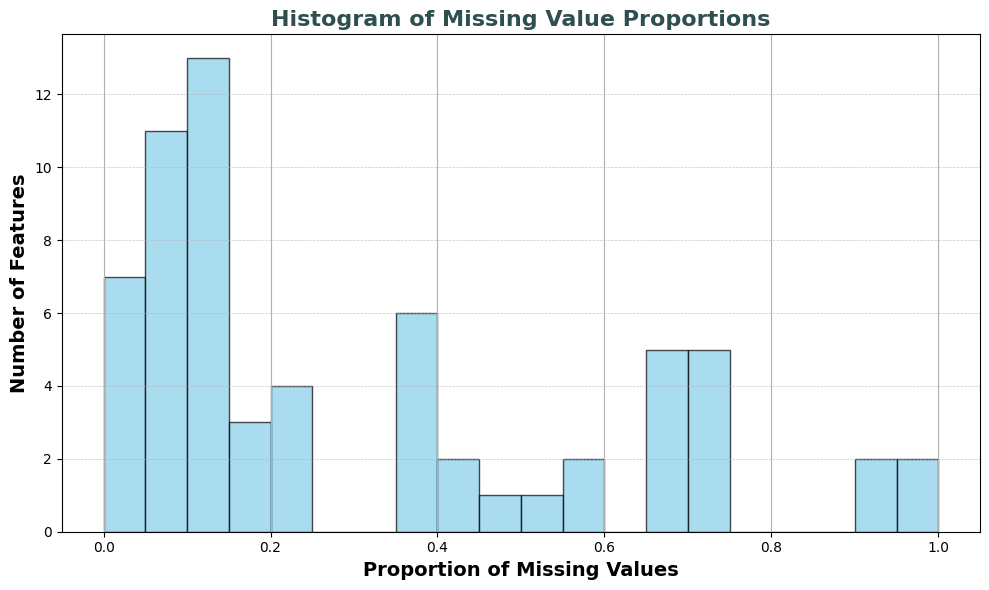

In [35]:
plot_missing_dist(data_w_target)

## Removing sparse columns

In [36]:
threshold = len(data_w_target) * 0.6

# Drop columns with less than 60% of filled values
data_w_target = data_w_target.dropna(axis=1, thresh=threshold)

In [37]:
selected_cols = [x for x in data_w_target.columns if x != 'SepsisLabel']
selected_cols

['visit_occurrence_id',
 'person_id',
 'measurement_datetime',
 'Base excess in Venous blood by calculation',
 'Potassium [Moles/volume] in Blood',
 'Bilirubin.total [Moles/volume] in Serum or Plasma',
 'Neutrophil Ab [Units/volume] in Serum',
 'Hematocrit [Volume Fraction] of Blood',
 'Glucose [Moles/volume] in Serum or Plasma',
 'Chloride [Moles/volume] in Blood',
 'Sodium [Moles/volume] in Serum or Plasma',
 'C reactive protein [Mass/volume] in Serum or Plasma',
 'Carbon dioxide [Partial pressure] in Venous blood',
 'Oxygen [Partial pressure] in Venous blood',
 'Bicarbonate [Moles/volume] in Venous blood',
 'Prothrombin time (PT)',
 'Procalcitonin [Mass/volume] in Serum or Plasma',
 'Lactate [Moles/volume] in Blood',
 'Creatinine [Mass/volume] in Blood',
 'Fibrinogen measurement',
 'Partial thromboplastin time',
 ' activated',
 'Total white blood count',
 'Platelet count',
 'White blood cell count',
 'Blood arterial pH',
 'Hemoglobin [Moles/volume] in Blood',
 'Body temperature',
 '

In [38]:
train_data = data_filtered[selected_cols + ['SepsisLabel']] # with and without labels
train_data

,visit_occurrence_id,person_id,measurement_datetime,Base excess in Venous blood by calculation,Potassium [Moles/volume] in Blood,Bilirubin.total [Moles/volume] in Serum or Plasma,Neutrophil Ab [Units/volume] in Serum,Hematocrit [Volume Fraction] of Blood,Glucose [Moles/volume] in Serum or Plasma,Chloride [Moles/volume] in Blood,Sodium [Moles/volume] in Serum or Plasma,C reactive protein [Mass/volume] in Serum or Plasma,Carbon dioxide [Partial pressure] in Venous blood,Oxygen [Partial pressure] in Venous blood,Bicarbonate [Moles/volume] in Venous blood,Prothrombin time (PT),Procalcitonin [Mass/volume] in Serum or Plasma,Lactate [Moles/volume] in Blood,Creatinine [Mass/volume] in Blood,Fibrinogen measurement,Partial thromboplastin time,activated,Total white blood count,Platelet count,White blood cell count,Blood arterial pH,Hemoglobin [Moles/volume] in Blood,Body temperature,Left pupil Diameter Auto,Right pupil Diameter Auto,Glasgow coma scale,Capillary refill [Time],Pulse,Arterial pulse pressure,Right pupil Pupillary response,Left pupil Pupillary response,drug_concept_id,route_concept_id,procedure,admission_reason,id,age_in_months,gender,SepsisLabel
0,5.945249e+07,510305,2019-07-01 16:00:00,-3.4,3.72,NaN,NaN,24.8,NaN,109.0,135.4,99.6,32.2,40.0,20.4,NaN,NaN,NaN,35.4,NaN,NaN,4.0,44.0,NaN,7.42,8.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,510305_59452488,25.0,FEMALE,0.0
1,5.945249e+07,510305,2019-07-01 17:00:00,-3.4,3.72,NaN,2.5,24.8,NaN,109.0,135.4,99.6,32.2,40.0,20.4,NaN,NaN,NaN,35.4,NaN,NaN,4.0,44.0,0.6,7.42,8.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,510305_59452488,25.0,FEMALE,0.0
2,5.945249e+07,510305,2019-07-02 10:00:00,-3.4,3.72,NaN,2.5,24.8,NaN,109.0,135.4,99.6,32.2,40.0,20.4,NaN,NaN,NaN,35.4,NaN,NaN,4.0,44.0,0.6,7.42,8.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,meropenem,Intravenous,NaN,NaN,510305_59452488,25.0,FEMALE,NaN
3,5.945249e+07,510305,2019-07-02 13:00:00,-3.4,3.72,NaN,2.5,24.8,NaN,109.0,135.4,99.6,32.2,40.0,20.4,NaN,NaN,NaN,35.4,NaN,NaN,4.0,44.0,0.6,7.42,8.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,meropenem,Intravenous,NaN,NaN,510305_59452488,25.0,FEMALE,0.0
4,5.945249e+07,510305,2019-07-02 17:00:00,-3.4,3.72,NaN,2.5,24.8,NaN,109.0,135.4,99.6,32.2,40.0,20.4,NaN,NaN,NaN,35.4,NaN,NaN,4.0,44.0,0.6,7.42,8.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,meropenem,Intravenous,NaN,NaN,510305_59452488,25.0,FEMALE,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1081494,1.464914e+09,2146982383,2019-12-25 16:00:00,2.1,4.90,NaN,NaN,NaN,NaN,102.0,135.0,54.9,48.6,37.0,27.0,NaN,0.16,1.9,NaN,NaN,NaN,NaN,NaN,NaN,7.36,NaN,1.31,36.7,3.0,3.0,15.0,Normal capillary filling,Present,Present,Normal,Normal,tobramycin,Topical,NaN,Médico,2146982383_1464914453,2.0,MALE,NaN
1081495,1.464914e+09,2146982383,2019-12-26 00:00:00,2.1,4.90,NaN,NaN,NaN,NaN,102.0,135.0,54.9,48.6,37.0,27.0,NaN,0.16,1.9,NaN,NaN,NaN,NaN,NaN,NaN,7.36,NaN,1.31,36.7,3.0,3.0,15.0,Normal capillary filling,Present,Present,Normal,Normal,tobramycin,Topical,NaN,Médico,2146982383_1464914453,2.0,MALE,NaN
1081496,1.464914e+09,2146982383,2019-12-26 16:00:00,2.1,4.90,NaN,NaN,NaN,NaN,102.0,135.0,54.9,48.6,37.0,27.0,NaN,0.16,1.9,NaN,NaN,NaN,NaN,NaN,NaN,7.36,NaN,1.31,36.7,3.0,3.0,15.0,Normal capillary filling,Present,Present,Normal,Normal,tobramycin,Topical,NaN,Médico,2146982383_1464914453,2.0,MALE,NaN
1081497,1.464914e+09,2146982383,2019-12-27 00:00:00,2.1,4.90,NaN,NaN,NaN,NaN,102.0,135.0,54.9,48.6,37.0,27.0,NaN,0.16,1.9,NaN,NaN,NaN,NaN,NaN,NaN,7.36,NaN,1.31,36.7,3.0,3.0,15.0,Normal capillary filling,Present,Present,Normal,Normal,tobramycin,Topical,NaN,Médico,2146982383_1464914453,2.0,MALE,NaN


In [39]:
train_data.to_csv(f'train_data_preprocessed.csv', index=False)

In [40]:
data_test_filtered = data_test_filtered[selected_cols]
data_test_filtered

,visit_occurrence_id,person_id,measurement_datetime,Base excess in Venous blood by calculation,Potassium [Moles/volume] in Blood,Bilirubin.total [Moles/volume] in Serum or Plasma,Neutrophil Ab [Units/volume] in Serum,Hematocrit [Volume Fraction] of Blood,Glucose [Moles/volume] in Serum or Plasma,Chloride [Moles/volume] in Blood,Sodium [Moles/volume] in Serum or Plasma,C reactive protein [Mass/volume] in Serum or Plasma,Carbon dioxide [Partial pressure] in Venous blood,Oxygen [Partial pressure] in Venous blood,Bicarbonate [Moles/volume] in Venous blood,Prothrombin time (PT),Procalcitonin [Mass/volume] in Serum or Plasma,Lactate [Moles/volume] in Blood,Creatinine [Mass/volume] in Blood,Fibrinogen measurement,Partial thromboplastin time,activated,Total white blood count,Platelet count,White blood cell count,Blood arterial pH,Hemoglobin [Moles/volume] in Blood,Body temperature,Left pupil Diameter Auto,Right pupil Diameter Auto,Glasgow coma scale,Capillary refill [Time],Pulse,Arterial pulse pressure,Right pupil Pupillary response,Left pupil Pupillary response,drug_concept_id,route_concept_id,procedure,admission_reason,id,age_in_months,gender
0,1825257182,1000733604,2020-10-28 19:00:00,-2.0,3.9,NaN,10.8,37.7,NaN,105.0,139.0,NaN,54.9,40.0,24.0,NaN,NaN,1.2,NaN,NaN,NaN,14.2,269.0,NaN,7.26,13.2,1.37,NaN,NaN,NaN,NaN,Normal capillary filling,Present,Present,NaN,NaN,NaN,NaN,NaN,Quirúrgico - Electivo,1000733604_1825257182,3.0,FEMALE
1,1825257182,1000733604,2020-10-28 20:00:00,-2.0,3.9,NaN,10.8,37.7,8.2,105.0,139.0,2.1,54.9,40.0,24.0,14.5,0.03,1.2,36.0,2.4,29.0,14.2,269.0,NaN,7.26,13.2,1.37,NaN,3.0,3.0,15.0,Normal capillary filling,Present,Present,Normal,Normal,NaN,NaN,NaN,Quirúrgico - Electivo,1000733604_1825257182,3.0,FEMALE
2,1825257182,1000733604,2020-10-28 22:00:00,-2.0,3.9,NaN,10.8,37.7,8.2,105.0,139.0,2.1,54.9,40.0,24.0,14.5,0.03,1.2,36.0,2.4,29.0,14.2,269.0,NaN,7.26,13.2,1.37,36.5,3.0,3.0,15.0,Normal capillary filling,Present,Present,Normal,Normal,NaN,NaN,NaN,Quirúrgico - Electivo,1000733604_1825257182,3.0,FEMALE
3,1825257182,1000733604,2020-10-28 23:00:00,-2.0,3.9,NaN,10.8,37.7,8.2,105.0,139.0,2.1,54.9,40.0,24.0,14.5,0.03,1.2,36.0,2.4,29.0,14.2,269.0,NaN,7.26,13.2,1.37,35.8,3.0,3.0,15.0,Normal capillary filling,Present,Present,Normal,Normal,NaN,NaN,NaN,Quirúrgico - Electivo,1000733604_1825257182,3.0,FEMALE
4,1825257182,1000733604,2020-10-29 01:00:00,-2.0,3.9,NaN,10.8,37.7,8.2,105.0,139.0,2.1,54.9,40.0,24.0,14.5,0.03,1.2,36.0,2.4,29.0,14.2,269.0,NaN,7.26,13.2,1.37,36.0,3.0,3.0,15.0,Normal capillary filling,Present,Present,Normal,Normal,NaN,NaN,NaN,Quirúrgico - Electivo,1000733604_1825257182,3.0,FEMALE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
447658,1546495182,997729340,2023-03-28 07:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.5,2.5,2.5,15.0,Normal capillary filling,Present,Present,Normal,Normal,amoxicillin,Oral,NaN,Médico,997729340_1546495182,3.0,MALE
447659,1546495182,997729340,2023-03-28 09:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.2,2.5,2.5,15.0,Normal capillary filling,Present,Present,Normal,Normal,amoxicillin,Oral,NaN,Médico,997729340_1546495182,3.0,MALE
447660,1546495182,997729340,2023-03-29 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.2,2.5,2.5,15.0,Normal capillary filling,Present,Present,Normal,Normal,amoxicillin,Oral,NaN,Médico,997729340_1546495182,3.0,MALE
447661,1546495182,997729340,2023-03-30 09:00:00,NaN,4.3,NaN,NaN,NaN,3.8,111.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.35,35.2,2.5,2.5,15.0,Normal capillary filling,Present,Present,Normal,Normal,amoxicillin,Oral,NaN,Médico,997729340_1546495182,3.0,MALE


In [41]:
test_set.shape

(130483, 2)

In [42]:
test_set_full = test_set.merge(data_test_filtered, how='outer')
test_set_full

,person_id,measurement_datetime,visit_occurrence_id,Base excess in Venous blood by calculation,Potassium [Moles/volume] in Blood,Bilirubin.total [Moles/volume] in Serum or Plasma,Neutrophil Ab [Units/volume] in Serum,Hematocrit [Volume Fraction] of Blood,Glucose [Moles/volume] in Serum or Plasma,Chloride [Moles/volume] in Blood,Sodium [Moles/volume] in Serum or Plasma,C reactive protein [Mass/volume] in Serum or Plasma,Carbon dioxide [Partial pressure] in Venous blood,Oxygen [Partial pressure] in Venous blood,Bicarbonate [Moles/volume] in Venous blood,Prothrombin time (PT),Procalcitonin [Mass/volume] in Serum or Plasma,Lactate [Moles/volume] in Blood,Creatinine [Mass/volume] in Blood,Fibrinogen measurement,Partial thromboplastin time,activated,Total white blood count,Platelet count,White blood cell count,Blood arterial pH,Hemoglobin [Moles/volume] in Blood,Body temperature,Left pupil Diameter Auto,Right pupil Diameter Auto,Glasgow coma scale,Capillary refill [Time],Pulse,Arterial pulse pressure,Right pupil Pupillary response,Left pupil Pupillary response,drug_concept_id,route_concept_id,procedure,admission_reason,id,age_in_months,gender
0,3858662,2019-11-28 17:00:00,1552488723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,methylprednisolone,Intravenous,NaN,NaN,3858662_1552488723,72.0,MALE
1,3858662,2019-11-29 00:00:00,1552488723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,methylprednisolone,Intravenous,NaN,Médico,3858662_1552488723,72.0,MALE
2,3858662,2019-11-29 01:00:00,1552488723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.7,NaN,NaN,15.0,Normal capillary filling,Present,Present,NaN,NaN,methylprednisolone,Intravenous,NaN,Médico,3858662_1552488723,72.0,MALE
3,3858662,2019-11-29 03:00:00,1552488723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.4,NaN,NaN,15.0,Normal capillary filling,Present,Present,NaN,NaN,methylprednisolone,Intravenous,NaN,Médico,3858662_1552488723,72.0,MALE
4,3858662,2019-11-29 05:00:00,1552488723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.8,NaN,NaN,15.0,Normal capillary filling,Present,Present,NaN,NaN,methylprednisolone,Intravenous,NaN,Médico,3858662_1552488723,72.0,MALE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
447658,2139900904,2024-10-31 16:00:00,1223148603,-3.4,4.3,6.0,0.5,29.8,5.4,108.0,141.0,31.8,37.0,47.0,21.0,13.6,0.05,1.3,49.9,6.5,34.4,2.0,167.0,0.0,7.37,10.6,1.3,35.8,3.0,3.0,15.0,Normal capillary filling,Present,Present,Normal,Normal,micafungin,Intravenous,Cannulation,Médico,2139900904_1223148603,170.0,MALE
447659,2139900904,2024-10-31 17:00:00,1223148603,-3.4,4.3,6.0,0.5,29.8,5.4,108.0,141.0,31.8,37.0,47.0,21.0,13.6,0.05,1.3,49.9,6.5,34.4,2.0,167.0,0.0,7.37,10.6,1.3,35.8,3.0,3.0,15.0,Normal capillary filling,Present,Present,Normal,Normal,micafungin,Intravenous,Cannulation,Médico,2139900904_1223148603,170.0,MALE
447660,2139900904,2024-11-05 09:00:00,1223148603,-3.4,4.3,6.0,0.5,32.5,5.4,108.0,141.0,31.8,37.0,47.0,21.0,13.6,0.05,1.3,49.9,6.5,34.4,2.9,451.0,0.0,7.37,11.2,1.3,35.8,3.0,3.0,15.0,Normal capillary filling,Present,Present,Normal,Normal,micafungin,Intravenous,Cannulation,Médico,2139900904_1223148603,170.0,MALE
447661,2139900904,2024-11-05 10:00:00,1223148603,-3.4,4.2,4.4,0.5,32.5,6.3,105.0,139.0,31.8,37.0,47.0,21.0,12.8,0.05,1.3,53.1,5.4,32.7,2.9,451.0,0.0,7.37,11.2,1.3,35.8,3.0,3.0,15.0,Normal capillary filling,Present,Present,Normal,Normal,micafungin,Intravenous,Cannulation,Médico,2139900904_1223148603,170.0,MALE


In [43]:
test_set_full.to_csv(f'test_data_preprocessed.csv', index=False)

# Data Preprocessing pt. 2

In [394]:
# 1st for train data
data = pd.read_csv("/kaggle/input/phems-dataset-outer/train_data_preprocessed.csv") # If you want to skip the previous section, read from the dataset.
# data = pd.read_csv("/kaggle/working/train_data_preprocessed.csv") # If you ran the previous section, you can use the newly generated csv as well.

# then for test data
data_test = pd.read_csv("/kaggle/input/phems-dataset-outer/test_data_preprocessed.csv") # If you want to skip the previous section, read from the dataset.
# data_test = pd.read_csv("/kaggle/working/test_data_preprocessed.csv") # If you ran the previous section, you can use the newly generated csv as well.

In [395]:
print(f"Train shape {data.shape}")
print(f"Test shape {data_test.shape}")

Train shape (1081499, 44)
Test shape (447663, 44)


In [396]:
features = [
       'Base excess in Venous blood by calculation',
       'Potassium [Moles/volume] in Blood',
       'Bilirubin.total [Moles/volume] in Serum or Plasma',
       'Neutrophil Ab [Units/volume] in Serum',
       'Hematocrit [Volume Fraction] of Blood',
       'Glucose [Moles/volume] in Serum or Plasma',
       'Chloride [Moles/volume] in Blood',
       'Sodium [Moles/volume] in Serum or Plasma',
       'C reactive protein [Mass/volume] in Serum or Plasma',
       'Carbon dioxide [Partial pressure] in Venous blood',
       'Oxygen [Partial pressure] in Venous blood',
       'Bicarbonate [Moles/volume] in Venous blood', 'Prothrombin time (PT)',
       'Procalcitonin [Mass/volume] in Serum or Plasma',
       'Lactate [Moles/volume] in Blood', 'Creatinine [Mass/volume] in Blood',
       'Fibrinogen measurement', 'Partial thromboplastin time', ' activated',
       'Total white blood count', 'Platelet count', 'White blood cell count',
       'Blood arterial pH', 'Hemoglobin [Moles/volume] in Blood',
       'Body temperature', 'Left pupil Diameter Auto',
       'Right pupil Diameter Auto', 'Glasgow coma scale']

In [397]:
# assumed that 0 is absence of the measurements
data[features] = data[features].replace(0, np.nan)

data = data[~data['measurement_datetime'].isna()]
data.shape

(1081483, 44)

In [398]:
# assumed that 0 is absence of the measurements
data_test[features] = data_test[features].replace(0, np.nan)

data_test = data_test[~data_test['measurement_datetime'].isna()]
data_test.shape

(447661, 44)

In [399]:
data = data.sort_values(by=['person_id', 'measurement_datetime'])
data['measurement_datetime'] = pd.to_datetime(data['measurement_datetime'])

In [400]:
data.shape

(1081483, 44)

In [401]:
data_test = data_test.sort_values(by=['person_id', 'measurement_datetime'])
data_test['measurement_datetime'] = pd.to_datetime(data_test['measurement_datetime'])

In [402]:
data_test.shape

(447661, 44)

## Fix duplicated rows

### One person_id-datetime has 2 different Sepsis label (Train)

In [403]:
# Step 1: Find duplicate rows based on 'visit_occurrence_id' and 'measurement_datetime'
duplicates = data[data.duplicated(['visit_occurrence_id', 'measurement_datetime'], keep=False)]

# Step 2: For each duplicate group, check if SepsisLabel has changed and display its values along with person_id
for (visit_id, datetime), group in duplicates.groupby(['visit_occurrence_id', 'measurement_datetime']):
    # Check if 'SepsisLabel' changes within the group
    if group['SepsisLabel'].nunique() > 1:
        # Get the old and new values of SepsisLabel and include person_id
        old_and_new_labels = group[['SepsisLabel', 'person_id', 'visit_occurrence_id', 'measurement_datetime']].drop_duplicates()
        
        print(f"SepsisLabel changed for visit_occurrence_id={visit_id}, measurement_datetime={datetime}:")
        print(old_and_new_labels)
        print("-" * 50)


SepsisLabel changed for visit_occurrence_id=649576332.0, measurement_datetime=2024-09-09 09:00:00:
        SepsisLabel   person_id  visit_occurrence_id measurement_datetime
824741          0.0  1576271591          649576332.0  2024-09-09 09:00:00
824742          1.0  1576271591          649576332.0  2024-09-09 09:00:00
--------------------------------------------------
SepsisLabel changed for visit_occurrence_id=795368156.0, measurement_datetime=2024-09-09 09:00:00:
        SepsisLabel   person_id  visit_occurrence_id measurement_datetime
824743          0.0  1576271591          795368156.0  2024-09-09 09:00:00
824744          1.0  1576271591          795368156.0  2024-09-09 09:00:00
--------------------------------------------------


In [404]:
# data[data["person_id"] == 1576271591].plot(x="measurement_datetime", y="SepsisLabel")
def plot_fix_label(data):
    start_time = "2024-09-08 09:00:00"
    end_time = "2024-09-10 10:00:00"  # Example: one-hour interval
    
    
    filtered_data = data[
        (data["person_id"] == 1576271591) &
        (data["measurement_datetime"] >= start_time) &
        (data["measurement_datetime"] < end_time)
    ]
    
    filtered_data.plot(x="measurement_datetime", y="SepsisLabel", kind="line", marker='o', title="Sepsis Label Over Time")

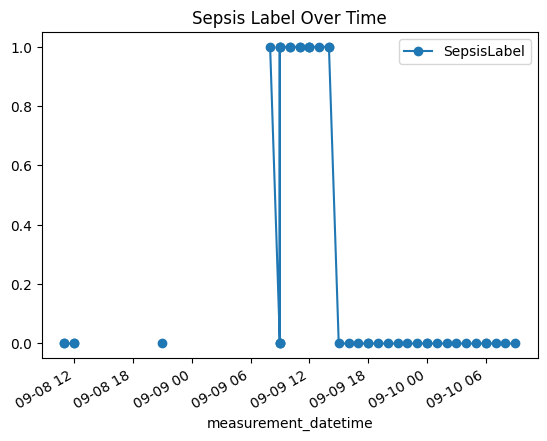

In [405]:
plot_fix_label(data)

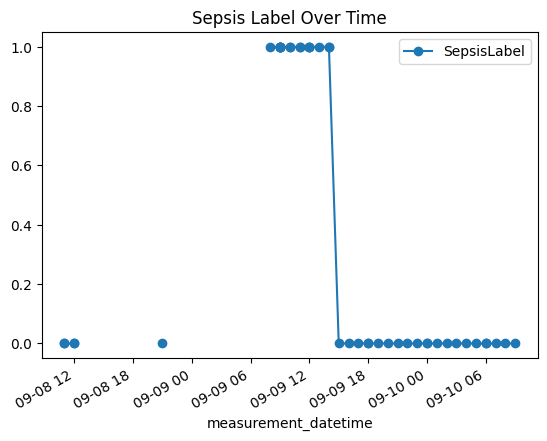

In [406]:
condition = (
    (data["person_id"] == 1576271591) &
    # (data["visit_occurrence_id"] == 649576332.0) &
    (data["measurement_datetime"] == "2024-09-09 09:00:00")
)

data.loc[condition, "SepsisLabel"] = 1

plot_fix_label(data)

In [407]:
numerical_cols = data.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = data.select_dtypes(exclude=[np.number]).columns.tolist()

categorical_cols = [x for x in categorical_cols if x not in ['measurement_datetime', 'Capillary refill [Time]', 'id', 'drug_concept_id', 'route_concept_id']] \
                    + ['visit_occurrence_id', 'person_id', 'SepsisLabel']

numerical_cols = [x for x in numerical_cols if x not in ['visit_occurrence_id',
 'person_id', 'SepsisLabel']]

In [408]:
def get_categoricals(data):
    categorical_agg = data.groupby(['person_id', 'measurement_datetime']).agg({
        'drug_concept_id': list,
        'route_concept_id': list}).reset_index()
    print("Initial shape: ", categorical_agg.shape)
    
    for col in ['drug_concept_id', 'route_concept_id']:
        for i, r in categorical_agg.iterrows():
            # contains ONLY nan
            if all(pd.isna(x) or x == 'nan' for x in r[col]):
                if col == 'drug_concept_id':
                    categorical_agg.at[i, col] = ['no_drug']
                else:
                    categorical_agg.at[i, col] = ['no_route']
            # if just nan among other non-nans        
            else:
                new = [x for x in r[col] if (str(x) != 'nan')]
                categorical_agg.at[i, col] = new
    print("Final shape: ", categorical_agg.shape)
    return categorical_agg


In [409]:
categorical_agg = get_categoricals(data)

Initial shape:  (1046847, 4)
Final shape:  (1046847, 4)


In [410]:
# troubleshoot
for i, r in categorical_agg.iterrows():
    if len(r['drug_concept_id']) > 1:
        print(r['drug_concept_id'])
        break

['fluconazole', 'piperacillin']


In [411]:
categorical_agg_test = get_categoricals(data_test)

Initial shape:  (433273, 4)
Final shape:  (433273, 4)


In [412]:
categorical_agg_test

,person_id,measurement_datetime,drug_concept_id,route_concept_id
0,3858662,2019-11-28 17:00:00,[methylprednisolone],[Intravenous]
1,3858662,2019-11-29 00:00:00,[methylprednisolone],[Intravenous]
2,3858662,2019-11-29 01:00:00,[methylprednisolone],[Intravenous]
3,3858662,2019-11-29 03:00:00,[methylprednisolone],[Intravenous]
4,3858662,2019-11-29 05:00:00,[methylprednisolone],[Intravenous]
...,...,...,...,...
433268,2139900904,2024-10-31 16:00:00,[micafungin],[Intravenous]
433269,2139900904,2024-10-31 17:00:00,[micafungin],[Intravenous]
433270,2139900904,2024-11-05 09:00:00,[micafungin],[Intravenous]
433271,2139900904,2024-11-05 10:00:00,[micafungin],[Intravenous]


In [413]:
print("Before initial shape: ", data.shape)
# Group by 'person_id' and 'measurement_datetime' to aggregate duplicates
data = (
    data.groupby(['person_id', 'measurement_datetime'], as_index=False)
    .agg({**{col: 'mean' for col in numerical_cols},
          **{col: 'first' for col in categorical_cols}})
)
print("Initial shape: ", data.shape)

data = data.merge(categorical_agg)
print("Final shape: ", data.shape)

Before initial shape:  (1081483, 44)
Initial shape:  (1046847, 40)
Final shape:  (1046847, 42)


In [414]:
# Remove sepsis label from categorical columns for Test
categorical_cols_test = [s for s in categorical_cols if s != "SepsisLabel"]
print("Before initial shape: ", data_test.shape)
# Group by 'person_id' and 'measurement_datetime' to aggregate duplicates
data_test = (
    data_test.groupby(['person_id', 'measurement_datetime'], as_index=False)
    .agg({**{col: 'mean' for col in numerical_cols}, # numerical columns are the same for train and test
          **{col: 'first' for col in categorical_cols_test}})
)
print("Initial shape: ", data_test.shape)

data_test = data_test.merge(categorical_agg_test)
print("Final shape: ", data_test.shape)

Before initial shape:  (447661, 44)
Initial shape:  (433273, 39)
Final shape:  (433273, 41)


In [415]:
# Define the impossible temperature thresholds
lower_threshold = 30  # Any temperature below 30°C is considered impossible
upper_threshold = 45  # Any temperature above 45°C is considered impossible

# Set impossible body temperatures to NaN
data['Body temperature'] = data['Body temperature'].apply(lambda x: pd.NA if x < lower_threshold or x > upper_threshold else x)
data['Body temperature'] = pd.to_numeric(data['Body temperature'], errors='coerce')
print(data.shape)

# Set impossible body temperatures to NaN
data_test['Body temperature'] = data_test['Body temperature'].apply(lambda x: pd.NA if x < lower_threshold or x > upper_threshold else x)
data_test['Body temperature'] = pd.to_numeric(data_test['Body temperature'], errors='coerce')
print(data_test.shape)

(1046847, 42)
(433273, 41)


In [419]:
data[data['route_concept_id'].isna()]

,measurement_datetime,Base excess in Venous blood by calculation,Potassium [Moles/volume] in Blood,Bilirubin.total [Moles/volume] in Serum or Plasma,Neutrophil Ab [Units/volume] in Serum,Hematocrit [Volume Fraction] of Blood,Glucose [Moles/volume] in Serum or Plasma,Chloride [Moles/volume] in Blood,Sodium [Moles/volume] in Serum or Plasma,C reactive protein [Mass/volume] in Serum or Plasma,Carbon dioxide [Partial pressure] in Venous blood,Oxygen [Partial pressure] in Venous blood,Bicarbonate [Moles/volume] in Venous blood,Prothrombin time (PT),Procalcitonin [Mass/volume] in Serum or Plasma,Lactate [Moles/volume] in Blood,Creatinine [Mass/volume] in Blood,Fibrinogen measurement,Partial thromboplastin time,activated,Total white blood count,Platelet count,White blood cell count,Blood arterial pH,Hemoglobin [Moles/volume] in Blood,Body temperature,Left pupil Diameter Auto,Right pupil Diameter Auto,Glasgow coma scale,age_in_months,Pulse,Arterial pulse pressure,Right pupil Pupillary response,Left pupil Pupillary response,procedure,admission_reason,gender,visit_occurrence_id,person_id,SepsisLabel,drug_concept_id,route_concept_id


In [420]:
data_test[data_test['route_concept_id'].isna()]

,measurement_datetime,Base excess in Venous blood by calculation,Potassium [Moles/volume] in Blood,Bilirubin.total [Moles/volume] in Serum or Plasma,Neutrophil Ab [Units/volume] in Serum,Hematocrit [Volume Fraction] of Blood,Glucose [Moles/volume] in Serum or Plasma,Chloride [Moles/volume] in Blood,Sodium [Moles/volume] in Serum or Plasma,C reactive protein [Mass/volume] in Serum or Plasma,Carbon dioxide [Partial pressure] in Venous blood,Oxygen [Partial pressure] in Venous blood,Bicarbonate [Moles/volume] in Venous blood,Prothrombin time (PT),Procalcitonin [Mass/volume] in Serum or Plasma,Lactate [Moles/volume] in Blood,Creatinine [Mass/volume] in Blood,Fibrinogen measurement,Partial thromboplastin time,activated,Total white blood count,Platelet count,White blood cell count,Blood arterial pH,Hemoglobin [Moles/volume] in Blood,Body temperature,Left pupil Diameter Auto,Right pupil Diameter Auto,Glasgow coma scale,age_in_months,Pulse,Arterial pulse pressure,Right pupil Pupillary response,Left pupil Pupillary response,procedure,admission_reason,gender,visit_occurrence_id,person_id,drug_concept_id,route_concept_id


# Feature Engineering

## TF-IDF

In [421]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pickle

In [422]:
def create_tf_idf_feat(data, mode='train', vectorizer_path="."):
    print("Initial shape:", data.shape)
    
    # Convert tuples/lists of drugs and routes into space-separated strings
    data['drug_str'] = data['drug_concept_id'].apply(lambda x: ' '.join(map(str, x)) if isinstance(x, (list, tuple)) else str(x))
    data['route_str'] = data['route_concept_id'].apply(lambda x: ' '.join(map(str, x)) if isinstance(x, (list, tuple)) else str(x))
    
    if mode == 'train':
        print("====> Training vectorizers")
        vectorizer_drug = TfidfVectorizer()
        vectorizer_route = TfidfVectorizer()
        
        tfidf_drugs = vectorizer_drug.fit_transform(data['drug_str'])
        tfidf_routes = vectorizer_route.fit_transform(data['route_str'])
        
        # Save trained vectorizers
        with open(f"{vectorizer_path}/vectorizer_drug.pk", "wb") as f:
            pickle.dump(vectorizer_drug, f)
        with open(f"{vectorizer_path}/vectorizer_route.pk", "wb") as f:
            pickle.dump(vectorizer_route, f)
    
    elif mode == 'test':
        print("====> Loading vectorizers for inference")
        vectorizer_drug = pickle.load(open(f"{vectorizer_path}/vectorizer_drug.pk", "rb"))
        vectorizer_route = pickle.load(open(f"{vectorizer_path}/vectorizer_route.pk", "rb"))
        print("vectorizer_route: ", vectorizer_route.vocabulary_.keys())
        print("vectorizer_drug: ", vectorizer_drug.vocabulary_.keys())
        
        tfidf_drugs = vectorizer_drug.transform(data['drug_str'])
        tfidf_routes = vectorizer_route.transform(data['route_str'])
    
    # Convert sparse matrices to DataFrames
    drug_features = vectorizer_drug.get_feature_names_out()
    route_features = vectorizer_route.get_feature_names_out()
    
    tfidf_drugs_df = pd.DataFrame(tfidf_drugs.toarray(), columns=drug_features)
    tfidf_routes_df = pd.DataFrame(tfidf_routes.toarray(), columns=route_features)
    
    # Ensure test features match train
    if mode == 'test':
        for col in set(drug_features) - set(tfidf_drugs_df.columns):
            tfidf_drugs_df[col] = 0
        for col in set(route_features) - set(tfidf_routes_df.columns):
            tfidf_routes_df[col] = 0
        tfidf_drugs_df = tfidf_drugs_df[drug_features]
        tfidf_routes_df = tfidf_routes_df[route_features]
    
    # Concatenate the TF-IDF features with the original data
    data_with_tfidf = pd.concat([data.reset_index(drop=True), tfidf_drugs_df, tfidf_routes_df], axis=1)
    print("Final shape:", data_with_tfidf.shape)
    
    return data_with_tfidf


**TF-IDF both train and test can be re-run using mode='test', then set vectorizer_path='/kaggle/input/phems-dataset-outer'.**

In [423]:
# data_tfidf = create_tf_idf_feat(data, mode='test', vectorizer_path='/kaggle/input/phems-dataset-outer')
data_tfidf = create_tf_idf_feat(data, mode='train')

Initial shape: (1046847, 42)
====> Training vectorizers
Final shape: (1046847, 105)


In [424]:
data_tfidf_test = create_tf_idf_feat(data_test, mode='test')

Initial shape: (433273, 41)
====> Loading vectorizers for inference
vectorizer_route:  dict_keys(['no_route', 'intravenous', 'intramuscula', 'oral', 'topical', 'intrapulmonary', 'otic', 'ophthalmic', 'nasal', 'rectal'])
vectorizer_drug:  dict_keys(['no_drug', 'meropenem', 'ertapenem', 'amoxicillin', 'cefazolin', 'methylprednisolone', 'prednisolone', 'azithromycin', 'fusidate', 'fluconazole', 'vancomycin', 'piperacillin', 'teicoplanin', 'ciprofloxacin', 'gentamicin', 'dexamethasone', 'erythromycin', 'ampicillin', 'ceftazidime', 'amikacin', 'dopamine', 'epinephrine', 'hydrocortisone', 'cefotaxime', 'fosfomycin', 'trimethoprim', 'colistin', 'mupirocin', 'milrinone', 'norepinephrine', 'dobutamine', 'levosimendan', 'phenylephrine', 'micafungin', 'linezolid', 'daptomycin', 'anidulafungin', 'tobramycin', 'clindamycin', 'cefuroxime', 'cefepime', 'cefadroxil', 'voriconazole', 'penicillin', 'isavuconazole', 'levofloxacin', 'clarithromycin', 'rifampin', 'isoproterenol', 'ceftolozane', 'nitrofuran

In [425]:
data_tfidf.sample(3)

,measurement_datetime,Base excess in Venous blood by calculation,Potassium [Moles/volume] in Blood,Bilirubin.total [Moles/volume] in Serum or Plasma,Neutrophil Ab [Units/volume] in Serum,Hematocrit [Volume Fraction] of Blood,Glucose [Moles/volume] in Serum or Plasma,Chloride [Moles/volume] in Blood,Sodium [Moles/volume] in Serum or Plasma,C reactive protein [Mass/volume] in Serum or Plasma,Carbon dioxide [Partial pressure] in Venous blood,Oxygen [Partial pressure] in Venous blood,Bicarbonate [Moles/volume] in Venous blood,Prothrombin time (PT),Procalcitonin [Mass/volume] in Serum or Plasma,Lactate [Moles/volume] in Blood,Creatinine [Mass/volume] in Blood,Fibrinogen measurement,Partial thromboplastin time,activated,Total white blood count,Platelet count,White blood cell count,Blood arterial pH,Hemoglobin [Moles/volume] in Blood,Body temperature,Left pupil Diameter Auto,Right pupil Diameter Auto,Glasgow coma scale,age_in_months,Pulse,Arterial pulse pressure,Right pupil Pupillary response,Left pupil Pupillary response,procedure,admission_reason,gender,visit_occurrence_id,person_id,SepsisLabel,drug_concept_id,route_concept_id,drug_str,route_str,amikacin,amoxicillin,ampicillin,anidulafungin,azithromycin,cefadroxil,cefazolin,cefepime,cefotaxime,ceftazidime,ceftolozane,cefuroxime,ciprofloxacin,clarithromycin,clindamycin,colistin,daptomycin,dexamethasone,dobutamine,dopamine,epinephrine,ertapenem,erythromycin,fluconazole,fosfomycin,fusidate,gentamicin,hydrocortisone,isavuconazole,isoproterenol,levofloxacin,levosimendan,linezolid,meropenem,methylprednisolone,micafungin,milrinone,mupirocin,nitrofurantoin,no_drug,norepinephrine,penicillin,phenylephrine,piperacillin,prednisolone,rifampin,teicoplanin,tobramycin,trimethoprim,vancomycin,voriconazole,intramuscula,intrapulmonary,intravenous,nasal,no_route,ophthalmic,oral,otic,rectal,topical
4270,2021-10-25 06:00:00,-3.4,3.3,NaN,5.3,30.8,5.5,113.0,143.0,2.5,51.3,31.0,22.5,12.4,0.03,1.1,41.2,2.4,21.5,8.4,252.0,NaN,7.27,11.0,1.25,36.7,2.5,2.5,15.0,89.0,Present,Present,Normal,Normal,Cannulation,Médico,MALE,9.116679e+08,8578054,NaN,[no_drug],[no_route],no_drug,no_route,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
605985,2024-07-01 12:00:00,3.5,3.8,0.6,14.6,25.9,7.6,105.0,140.0,78.4,38.7,112.0,27.2,14.7,0.10,1.0,54.0,6.5,27.0,16.2,173.0,NaN,7.46,9.0,1.15,36.7,3.0,3.0,15.0,170.0,Present,Present,Normal,Normal,Cannulation,Quirúrgico - Electivo,FEMALE,1.269666e+09,1279277399,0.0,[dexamethasone],[Intravenous],dexamethasone,Intravenous,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
971872,2019-12-28 01:00:00,1.6,3.0,NaN,2.3,26.9,NaN,101.0,133.0,164.1,47.7,38.0,26.4,NaN,0.86,2.0,28.8,NaN,NaN,3.3,367.0,0.1,7.36,8.6,1.27,34.4,2.0,2.0,3.0,2.0,Present,Present,Normal,Normal,None,Médico,MALE,1.899440e+09,1977727120,0.0,[tobramycin],[Topical],tobramycin,Topical,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [426]:
data_tfidf_test.sample(3)

,measurement_datetime,Base excess in Venous blood by calculation,Potassium [Moles/volume] in Blood,Bilirubin.total [Moles/volume] in Serum or Plasma,Neutrophil Ab [Units/volume] in Serum,Hematocrit [Volume Fraction] of Blood,Glucose [Moles/volume] in Serum or Plasma,Chloride [Moles/volume] in Blood,Sodium [Moles/volume] in Serum or Plasma,C reactive protein [Mass/volume] in Serum or Plasma,Carbon dioxide [Partial pressure] in Venous blood,Oxygen [Partial pressure] in Venous blood,Bicarbonate [Moles/volume] in Venous blood,Prothrombin time (PT),Procalcitonin [Mass/volume] in Serum or Plasma,Lactate [Moles/volume] in Blood,Creatinine [Mass/volume] in Blood,Fibrinogen measurement,Partial thromboplastin time,activated,Total white blood count,Platelet count,White blood cell count,Blood arterial pH,Hemoglobin [Moles/volume] in Blood,Body temperature,Left pupil Diameter Auto,Right pupil Diameter Auto,Glasgow coma scale,age_in_months,Pulse,Arterial pulse pressure,Right pupil Pupillary response,Left pupil Pupillary response,procedure,admission_reason,gender,visit_occurrence_id,person_id,drug_concept_id,route_concept_id,drug_str,route_str,amikacin,amoxicillin,ampicillin,anidulafungin,azithromycin,cefadroxil,cefazolin,cefepime,cefotaxime,ceftazidime,ceftolozane,cefuroxime,ciprofloxacin,clarithromycin,clindamycin,colistin,daptomycin,dexamethasone,dobutamine,dopamine,epinephrine,ertapenem,erythromycin,fluconazole,fosfomycin,fusidate,gentamicin,hydrocortisone,isavuconazole,isoproterenol,levofloxacin,levosimendan,linezolid,meropenem,methylprednisolone,micafungin,milrinone,mupirocin,nitrofurantoin,no_drug,norepinephrine,penicillin,phenylephrine,piperacillin,prednisolone,rifampin,teicoplanin,tobramycin,trimethoprim,vancomycin,voriconazole,intramuscula,intrapulmonary,intravenous,nasal,no_route,ophthalmic,oral,otic,rectal,topical
315773,2020-01-29 05:00:00,0.4,4.5,13.9,19.1,27.3,4.1,107.0,141.0,70.9,40.3,42.0,24.6,NaN,0.10,1.7,29.2,NaN,NaN,27.3,198.0,0.5,7.40,9.2,1.06,36.9,2.5,2.5,15.0,0.0,Present,Present,Normal,Normal,Cannulation,Quirúrgico - Urgencia,FEMALE,386867611,1504870440,[meropenem],[Intravenous],meropenem,Intravenous,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
236605,2020-06-01 14:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.4,2.0,2.0,15.0,158.0,Present,Present,Normal,Normal,Cannulation,Médico,FEMALE,199660981,1152701981,[no_drug],[no_route],no_drug,no_route,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
293538,2023-12-20 02:00:00,1.0,4.5,4.4,12.3,23.4,5.0,102.0,135.0,2.1,46.3,44.0,25.8,19.0,0.13,1.3,25.5,7.0,37.6,14.5,400.0,0.1,7.37,7.7,1.25,36.4,2.5,2.5,15.0,12.0,Present,Present,Normal,Normal,Exteriorization of trachea,Médico,MALE,536563140,1430074021,[colistin],[Intrapulmonary],colistin,Intrapulmonary,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Statistical features

In [427]:
from collections import Counter

In [428]:
def calculate_rolling_aggregates(data, numerical_cols, group_col='person_id', time_col='measurement_datetime', window_time='12H'):
    # Create a copy of the DataFrame to avoid modifying the original
    data_copy = data.copy()
    
    # Ensure the time column is in datetime format
    data_copy[time_col] = pd.to_datetime(data_copy[time_col])
    
    # Set the time column as the index (on the copy)
    data_copy = data_copy.set_index(time_col)
    
    # Process numerical columns: rolling mean
    for col in numerical_cols:
        data_copy[f'{col}_rolling_{window_time}_mean'] = (
            data_copy.groupby(group_col)[col]
            .rolling(window=window_time, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )
    
    # Reset the index to bring the time column back as a regular column
    data_copy = data_copy.reset_index()
    
    return data_copy

In [429]:
numerical_cols_new = [x for x in numerical_cols if x not in ['Left pupil Diameter Auto',
 'Right pupil Diameter Auto',
 'Glasgow coma scale',
 ' activated',
 'age_in_months']]
numerical_cols_new

['Base excess in Venous blood by calculation',
 'Potassium [Moles/volume] in Blood',
 'Bilirubin.total [Moles/volume] in Serum or Plasma',
 'Neutrophil Ab [Units/volume] in Serum',
 'Hematocrit [Volume Fraction] of Blood',
 'Glucose [Moles/volume] in Serum or Plasma',
 'Chloride [Moles/volume] in Blood',
 'Sodium [Moles/volume] in Serum or Plasma',
 'C reactive protein [Mass/volume] in Serum or Plasma',
 'Carbon dioxide [Partial pressure] in Venous blood',
 'Oxygen [Partial pressure] in Venous blood',
 'Bicarbonate [Moles/volume] in Venous blood',
 'Prothrombin time (PT)',
 'Procalcitonin [Mass/volume] in Serum or Plasma',
 'Lactate [Moles/volume] in Blood',
 'Creatinine [Mass/volume] in Blood',
 'Fibrinogen measurement',
 'Partial thromboplastin time',
 'Total white blood count',
 'Platelet count',
 'White blood cell count',
 'Blood arterial pH',
 'Hemoglobin [Moles/volume] in Blood',
 'Body temperature']

In [430]:
print(data_tfidf.shape)
data_w_feat = calculate_rolling_aggregates(data_tfidf, numerical_cols_new, \
                                           window_time = '3H')
print(data_w_feat.shape)
data_w_feat = calculate_rolling_aggregates(data_w_feat, numerical_cols_new,\
                                           window_time = '6H')
print(data_w_feat.shape)

(1046847, 105)
(1046847, 129)
(1046847, 153)


In [431]:
data_w_feat.sample(4)

,measurement_datetime,Base excess in Venous blood by calculation,Potassium [Moles/volume] in Blood,Bilirubin.total [Moles/volume] in Serum or Plasma,Neutrophil Ab [Units/volume] in Serum,Hematocrit [Volume Fraction] of Blood,Glucose [Moles/volume] in Serum or Plasma,Chloride [Moles/volume] in Blood,Sodium [Moles/volume] in Serum or Plasma,C reactive protein [Mass/volume] in Serum or Plasma,Carbon dioxide [Partial pressure] in Venous blood,Oxygen [Partial pressure] in Venous blood,Bicarbonate [Moles/volume] in Venous blood,Prothrombin time (PT),Procalcitonin [Mass/volume] in Serum or Plasma,Lactate [Moles/volume] in Blood,Creatinine [Mass/volume] in Blood,Fibrinogen measurement,Partial thromboplastin time,activated,Total white blood count,Platelet count,White blood cell count,Blood arterial pH,Hemoglobin [Moles/volume] in Blood,Body temperature,Left pupil Diameter Auto,Right pupil Diameter Auto,Glasgow coma scale,age_in_months,Pulse,Arterial pulse pressure,Right pupil Pupillary response,Left pupil Pupillary response,procedure,admission_reason,gender,visit_occurrence_id,person_id,SepsisLabel,drug_concept_id,route_concept_id,drug_str,route_str,amikacin,amoxicillin,ampicillin,anidulafungin,azithromycin,cefadroxil,cefazolin,cefepime,cefotaxime,ceftazidime,ceftolozane,cefuroxime,ciprofloxacin,clarithromycin,clindamycin,colistin,daptomycin,dexamethasone,dobutamine,dopamine,epinephrine,ertapenem,erythromycin,fluconazole,fosfomycin,fusidate,gentamicin,hydrocortisone,isavuconazole,isoproterenol,levofloxacin,levosimendan,linezolid,meropenem,methylprednisolone,micafungin,milrinone,mupirocin,nitrofurantoin,no_drug,norepinephrine,penicillin,phenylephrine,piperacillin,prednisolone,rifampin,teicoplanin,tobramycin,trimethoprim,vancomycin,voriconazole,intramuscula,intrapulmonary,intravenous,nasal,no_route,ophthalmic,oral,otic,rectal,topical,Base excess in Venous blood by calculation_rolling_3H_mean,Potassium [Moles/volume] in Blood_rolling_3H_mean,Bilirubin.total [Moles/volume] in Serum or Plasma_rolling_3H_mean,Neutrophil Ab [Units/volume] in Serum_rolling_3H_mean,Hematocrit [Volume Fraction] of Blood_rolling_3H_mean,Glucose [Moles/volume] in Serum or Plasma_rolling_3H_mean,Chloride [Moles/volume] in Blood_rolling_3H_mean,Sodium [Moles/volume] in Serum or Plasma_rolling_3H_mean,C reactive protein [Mass/volume] in Serum or Plasma_rolling_3H_mean,Carbon dioxide [Partial pressure] in Venous blood_rolling_3H_mean,Oxygen [Partial pressure] in Venous blood_rolling_3H_mean,Bicarbonate [Moles/volume] in Venous blood_rolling_3H_mean,Prothrombin time (PT)_rolling_3H_mean,Procalcitonin [Mass/volume] in Serum or Plasma_rolling_3H_mean,Lactate [Moles/volume] in Blood_rolling_3H_mean,Creatinine [Mass/volume] in Blood_rolling_3H_mean,Fibrinogen measurement_rolling_3H_mean,Partial thromboplastin time_rolling_3H_mean,Total white blood count_rolling_3H_mean,Platelet count_rolling_3H_mean,White blood cell count_rolling_3H_mean,Blood arterial pH_rolling_3H_mean,Hemoglobin [Moles/volume] in Blood_rolling_3H_mean,Body temperature_rolling_3H_mean,Base excess in Venous blood by calculation_rolling_6H_mean,Potassium [Moles/volume] in Blood_rolling_6H_mean,Bilirubin.total [Moles/volume] in Serum or Plasma_rolling_6H_mean,Neutrophil Ab [Units/volume] in Serum_rolling_6H_mean,Hematocrit [Volume Fraction] of Blood_rolling_6H_mean,Glucose [Moles/volume] in Serum or Plasma_rolling_6H_mean,Chloride [Moles/volume] in Blood_rolling_6H_mean,Sodium [Moles/volume] in Serum or Plasma_rolling_6H_mean,C reactive protein [Mass/volume] in Serum or Plasma_rolling_6H_mean,Carbon dioxide [Partial pressure] in Venous blood_rolling_6H_mean,Oxygen [Partial pressure] in Venous blood_rolling_6H_mean,Bicarbonate [Moles/volume] in Venous blood_rolling_6H_mean,Prothrombin time (PT)_rolling_6H_mean,Procalcitonin [Mass/volume] in Serum or Plasma_rolling_6H_mean,Lactate [Moles/volume] in Blood_rolling_6H_mean,Creatinine [Mass/volume] in Blood_rolling_6H_mean,Fibrinogen measurement_rolling_6H_mean,P

In [432]:
print(data_tfidf_test.shape)
data_w_feat_test = calculate_rolling_aggregates(data_tfidf_test, numerical_cols_new, \
                                           window_time = '3H')
print(data_w_feat_test.shape)
data_w_feat_test = calculate_rolling_aggregates(data_w_feat_test, numerical_cols_new, \
                                           window_time = '6H')
print(data_w_feat_test.shape)

(433273, 104)
(433273, 128)
(433273, 152)


In [433]:
data_w_feat_test.sample(4)

,measurement_datetime,Base excess in Venous blood by calculation,Potassium [Moles/volume] in Blood,Bilirubin.total [Moles/volume] in Serum or Plasma,Neutrophil Ab [Units/volume] in Serum,Hematocrit [Volume Fraction] of Blood,Glucose [Moles/volume] in Serum or Plasma,Chloride [Moles/volume] in Blood,Sodium [Moles/volume] in Serum or Plasma,C reactive protein [Mass/volume] in Serum or Plasma,Carbon dioxide [Partial pressure] in Venous blood,Oxygen [Partial pressure] in Venous blood,Bicarbonate [Moles/volume] in Venous blood,Prothrombin time (PT),Procalcitonin [Mass/volume] in Serum or Plasma,Lactate [Moles/volume] in Blood,Creatinine [Mass/volume] in Blood,Fibrinogen measurement,Partial thromboplastin time,activated,Total white blood count,Platelet count,White blood cell count,Blood arterial pH,Hemoglobin [Moles/volume] in Blood,Body temperature,Left pupil Diameter Auto,Right pupil Diameter Auto,Glasgow coma scale,age_in_months,Pulse,Arterial pulse pressure,Right pupil Pupillary response,Left pupil Pupillary response,procedure,admission_reason,gender,visit_occurrence_id,person_id,drug_concept_id,route_concept_id,drug_str,route_str,amikacin,amoxicillin,ampicillin,anidulafungin,azithromycin,cefadroxil,cefazolin,cefepime,cefotaxime,ceftazidime,ceftolozane,cefuroxime,ciprofloxacin,clarithromycin,clindamycin,colistin,daptomycin,dexamethasone,dobutamine,dopamine,epinephrine,ertapenem,erythromycin,fluconazole,fosfomycin,fusidate,gentamicin,hydrocortisone,isavuconazole,isoproterenol,levofloxacin,levosimendan,linezolid,meropenem,methylprednisolone,micafungin,milrinone,mupirocin,nitrofurantoin,no_drug,norepinephrine,penicillin,phenylephrine,piperacillin,prednisolone,rifampin,teicoplanin,tobramycin,trimethoprim,vancomycin,voriconazole,intramuscula,intrapulmonary,intravenous,nasal,no_route,ophthalmic,oral,otic,rectal,topical,Base excess in Venous blood by calculation_rolling_3H_mean,Potassium [Moles/volume] in Blood_rolling_3H_mean,Bilirubin.total [Moles/volume] in Serum or Plasma_rolling_3H_mean,Neutrophil Ab [Units/volume] in Serum_rolling_3H_mean,Hematocrit [Volume Fraction] of Blood_rolling_3H_mean,Glucose [Moles/volume] in Serum or Plasma_rolling_3H_mean,Chloride [Moles/volume] in Blood_rolling_3H_mean,Sodium [Moles/volume] in Serum or Plasma_rolling_3H_mean,C reactive protein [Mass/volume] in Serum or Plasma_rolling_3H_mean,Carbon dioxide [Partial pressure] in Venous blood_rolling_3H_mean,Oxygen [Partial pressure] in Venous blood_rolling_3H_mean,Bicarbonate [Moles/volume] in Venous blood_rolling_3H_mean,Prothrombin time (PT)_rolling_3H_mean,Procalcitonin [Mass/volume] in Serum or Plasma_rolling_3H_mean,Lactate [Moles/volume] in Blood_rolling_3H_mean,Creatinine [Mass/volume] in Blood_rolling_3H_mean,Fibrinogen measurement_rolling_3H_mean,Partial thromboplastin time_rolling_3H_mean,Total white blood count_rolling_3H_mean,Platelet count_rolling_3H_mean,White blood cell count_rolling_3H_mean,Blood arterial pH_rolling_3H_mean,Hemoglobin [Moles/volume] in Blood_rolling_3H_mean,Body temperature_rolling_3H_mean,Base excess in Venous blood by calculation_rolling_6H_mean,Potassium [Moles/volume] in Blood_rolling_6H_mean,Bilirubin.total [Moles/volume] in Serum or Plasma_rolling_6H_mean,Neutrophil Ab [Units/volume] in Serum_rolling_6H_mean,Hematocrit [Volume Fraction] of Blood_rolling_6H_mean,Glucose [Moles/volume] in Serum or Plasma_rolling_6H_mean,Chloride [Moles/volume] in Blood_rolling_6H_mean,Sodium [Moles/volume] in Serum or Plasma_rolling_6H_mean,C reactive protein [Mass/volume] in Serum or Plasma_rolling_6H_mean,Carbon dioxide [Partial pressure] in Venous blood_rolling_6H_mean,Oxygen [Partial pressure] in Venous blood_rolling_6H_mean,Bicarbonate [Moles/volume] in Venous blood_rolling_6H_mean,Prothrombin time (PT)_rolling_6H_mean,Procalcitonin [Mass/volume] in Serum or Plasma_rolling_6H_mean,Lactate [Moles/volume] in Blood_rolling_6H_mean,Creatinine [Mass/volume] in Blood_rolling_6H_mean,Fibrinogen measurement_rolling_6H_mean,Partial throm

## Standardized naming of columns

In [434]:
def rename_columns(data):
    data.columns = (
        data.columns
        .str.strip()  # Remove leading and trailing whitespace
        .str.replace(r'[^\w]', '_', regex=True)  # Replace special characters with underscores
        .str.replace(r'__+', '_', regex=True)  # Replace multiple underscores with a single one
        .str.lower()  # Convert to lowercase for consistency
    )
    
    print("Columns renamed successfully!")
    return data

In [435]:
data_w_feat = rename_columns(data_w_feat)
data_w_feat.head(3)

Columns renamed successfully!


,measurement_datetime,base_excess_in_venous_blood_by_calculation,potassium_moles_volume_in_blood,bilirubin_total_moles_volume_in_serum_or_plasma,neutrophil_ab_units_volume_in_serum,hematocrit_volume_fraction_of_blood,glucose_moles_volume_in_serum_or_plasma,chloride_moles_volume_in_blood,sodium_moles_volume_in_serum_or_plasma,c_reactive_protein_mass_volume_in_serum_or_plasma,carbon_dioxide_partial_pressure_in_venous_blood,oxygen_partial_pressure_in_venous_blood,bicarbonate_moles_volume_in_venous_blood,prothrombin_time_pt_,procalcitonin_mass_volume_in_serum_or_plasma,lactate_moles_volume_in_blood,creatinine_mass_volume_in_blood,fibrinogen_measurement,partial_thromboplastin_time,activated,total_white_blood_count,platelet_count,white_blood_cell_count,blood_arterial_ph,hemoglobin_moles_volume_in_blood,body_temperature,left_pupil_diameter_auto,right_pupil_diameter_auto,glasgow_coma_scale,age_in_months,pulse,arterial_pulse_pressure,right_pupil_pupillary_response,left_pupil_pupillary_response,procedure,admission_reason,gender,visit_occurrence_id,person_id,sepsislabel,drug_concept_id,route_concept_id,drug_str,route_str,amikacin,amoxicillin,ampicillin,anidulafungin,azithromycin,cefadroxil,cefazolin,cefepime,cefotaxime,ceftazidime,ceftolozane,cefuroxime,ciprofloxacin,clarithromycin,clindamycin,colistin,daptomycin,dexamethasone,dobutamine,dopamine,epinephrine,ertapenem,erythromycin,fluconazole,fosfomycin,fusidate,gentamicin,hydrocortisone,isavuconazole,isoproterenol,levofloxacin,levosimendan,linezolid,meropenem,methylprednisolone,micafungin,milrinone,mupirocin,nitrofurantoin,no_drug,norepinephrine,penicillin,phenylephrine,piperacillin,prednisolone,rifampin,teicoplanin,tobramycin,trimethoprim,vancomycin,voriconazole,intramuscula,intrapulmonary,intravenous,nasal,no_route,ophthalmic,oral,otic,rectal,topical,base_excess_in_venous_blood_by_calculation_rolling_3h_mean,potassium_moles_volume_in_blood_rolling_3h_mean,bilirubin_total_moles_volume_in_serum_or_plasma_rolling_3h_mean,neutrophil_ab_units_volume_in_serum_rolling_3h_mean,hematocrit_volume_fraction_of_blood_rolling_3h_mean,glucose_moles_volume_in_serum_or_plasma_rolling_3h_mean,chloride_moles_volume_in_blood_rolling_3h_mean,sodium_moles_volume_in_serum_or_plasma_rolling_3h_mean,c_reactive_protein_mass_volume_in_serum_or_plasma_rolling_3h_mean,carbon_dioxide_partial_pressure_in_venous_blood_rolling_3h_mean,oxygen_partial_pressure_in_venous_blood_rolling_3h_mean,bicarbonate_moles_volume_in_venous_blood_rolling_3h_mean,prothrombin_time_pt_rolling_3h_mean,procalcitonin_mass_volume_in_serum_or_plasma_rolling_3h_mean,lactate_moles_volume_in_blood_rolling_3h_mean,creatinine_mass_volume_in_blood_rolling_3h_mean,fibrinogen_measurement_rolling_3h_mean,partial_thromboplastin_time_rolling_3h_mean,total_white_blood_count_rolling_3h_mean,platelet_count_rolling_3h_mean,white_blood_cell_count_rolling_3h_mean,blood_arterial_ph_rolling_3h_mean,hemoglobin_moles_volume_in_blood_rolling_3h_mean,body_temperature_rolling_3h_mean,base_excess_in_venous_blood_by_calculation_rolling_6h_mean,potassium_moles_volume_in_blood_rolling_6h_mean,bilirubin_total_moles_volume_in_serum_or_plasma_rolling_6h_mean,neutrophil_ab_units_volume_in_serum_rolling_6h_mean,hematocrit_volume_fraction_of_blood_rolling_6h_mean,glucose_moles_volume_in_serum_or_plasma_rolling_6h_mean,chloride_moles_volume_in_blood_rolling_6h_mean,sodium_moles_volume_in_serum_or_plasma_rolling_6h_mean,c_reactive_protein_mass_volume_in_serum_or_plasma_rolling_6h_mean,carbon_dioxide_partial_pressure_in_venous_blood_rolling_6h_mean,oxygen_partial_pressure_in_venous_blood_rolling_6h_mean,bicarbonate_moles_volume_in_venous_blood_rolling_6h_mean,prothrombin_time_pt_rolling_6h_mean,procalcitonin_mass_volume_in_serum_or_plasma_rolling_6h_mean,lactate_moles_volume_in_blood_rolling_6h_mean,creatinine_mass_volume_in_blood_rolling_6h_mean,fibrinogen_measurement_rolling_6h_mean,partial_thromboplastin_time_rolling_6h_mean,total_white_blood_count_rolling_6h_mean,platelet_c

In [436]:
data_w_feat_test = rename_columns(data_w_feat_test)
data_w_feat_test.head(3)

Columns renamed successfully!


,measurement_datetime,base_excess_in_venous_blood_by_calculation,potassium_moles_volume_in_blood,bilirubin_total_moles_volume_in_serum_or_plasma,neutrophil_ab_units_volume_in_serum,hematocrit_volume_fraction_of_blood,glucose_moles_volume_in_serum_or_plasma,chloride_moles_volume_in_blood,sodium_moles_volume_in_serum_or_plasma,c_reactive_protein_mass_volume_in_serum_or_plasma,carbon_dioxide_partial_pressure_in_venous_blood,oxygen_partial_pressure_in_venous_blood,bicarbonate_moles_volume_in_venous_blood,prothrombin_time_pt_,procalcitonin_mass_volume_in_serum_or_plasma,lactate_moles_volume_in_blood,creatinine_mass_volume_in_blood,fibrinogen_measurement,partial_thromboplastin_time,activated,total_white_blood_count,platelet_count,white_blood_cell_count,blood_arterial_ph,hemoglobin_moles_volume_in_blood,body_temperature,left_pupil_diameter_auto,right_pupil_diameter_auto,glasgow_coma_scale,age_in_months,pulse,arterial_pulse_pressure,right_pupil_pupillary_response,left_pupil_pupillary_response,procedure,admission_reason,gender,visit_occurrence_id,person_id,drug_concept_id,route_concept_id,drug_str,route_str,amikacin,amoxicillin,ampicillin,anidulafungin,azithromycin,cefadroxil,cefazolin,cefepime,cefotaxime,ceftazidime,ceftolozane,cefuroxime,ciprofloxacin,clarithromycin,clindamycin,colistin,daptomycin,dexamethasone,dobutamine,dopamine,epinephrine,ertapenem,erythromycin,fluconazole,fosfomycin,fusidate,gentamicin,hydrocortisone,isavuconazole,isoproterenol,levofloxacin,levosimendan,linezolid,meropenem,methylprednisolone,micafungin,milrinone,mupirocin,nitrofurantoin,no_drug,norepinephrine,penicillin,phenylephrine,piperacillin,prednisolone,rifampin,teicoplanin,tobramycin,trimethoprim,vancomycin,voriconazole,intramuscula,intrapulmonary,intravenous,nasal,no_route,ophthalmic,oral,otic,rectal,topical,base_excess_in_venous_blood_by_calculation_rolling_3h_mean,potassium_moles_volume_in_blood_rolling_3h_mean,bilirubin_total_moles_volume_in_serum_or_plasma_rolling_3h_mean,neutrophil_ab_units_volume_in_serum_rolling_3h_mean,hematocrit_volume_fraction_of_blood_rolling_3h_mean,glucose_moles_volume_in_serum_or_plasma_rolling_3h_mean,chloride_moles_volume_in_blood_rolling_3h_mean,sodium_moles_volume_in_serum_or_plasma_rolling_3h_mean,c_reactive_protein_mass_volume_in_serum_or_plasma_rolling_3h_mean,carbon_dioxide_partial_pressure_in_venous_blood_rolling_3h_mean,oxygen_partial_pressure_in_venous_blood_rolling_3h_mean,bicarbonate_moles_volume_in_venous_blood_rolling_3h_mean,prothrombin_time_pt_rolling_3h_mean,procalcitonin_mass_volume_in_serum_or_plasma_rolling_3h_mean,lactate_moles_volume_in_blood_rolling_3h_mean,creatinine_mass_volume_in_blood_rolling_3h_mean,fibrinogen_measurement_rolling_3h_mean,partial_thromboplastin_time_rolling_3h_mean,total_white_blood_count_rolling_3h_mean,platelet_count_rolling_3h_mean,white_blood_cell_count_rolling_3h_mean,blood_arterial_ph_rolling_3h_mean,hemoglobin_moles_volume_in_blood_rolling_3h_mean,body_temperature_rolling_3h_mean,base_excess_in_venous_blood_by_calculation_rolling_6h_mean,potassium_moles_volume_in_blood_rolling_6h_mean,bilirubin_total_moles_volume_in_serum_or_plasma_rolling_6h_mean,neutrophil_ab_units_volume_in_serum_rolling_6h_mean,hematocrit_volume_fraction_of_blood_rolling_6h_mean,glucose_moles_volume_in_serum_or_plasma_rolling_6h_mean,chloride_moles_volume_in_blood_rolling_6h_mean,sodium_moles_volume_in_serum_or_plasma_rolling_6h_mean,c_reactive_protein_mass_volume_in_serum_or_plasma_rolling_6h_mean,carbon_dioxide_partial_pressure_in_venous_blood_rolling_6h_mean,oxygen_partial_pressure_in_venous_blood_rolling_6h_mean,bicarbonate_moles_volume_in_venous_blood_rolling_6h_mean,prothrombin_time_pt_rolling_6h_mean,procalcitonin_mass_volume_in_serum_or_plasma_rolling_6h_mean,lactate_moles_volume_in_blood_rolling_6h_mean,creatinine_mass_volume_in_blood_rolling_6h_mean,fibrinogen_measurement_rolling_6h_mean,partial_thromboplastin_time_rolling_6h_mean,total_white_blood_count_rolling_6h_mean,platelet_count_rolling

In [437]:
data_w_feat['id'] = data_w_feat['person_id'].astype(str) + '_' + data_w_feat['visit_occurrence_id'].astype(str)

In [438]:
data_w_feat_test['id'] = data_w_feat_test['person_id'].astype(str) + '_' + data_w_feat_test['visit_occurrence_id'].astype(str)

In [439]:
data_w_feat = filling_missing_values(data_w_feat)
data_w_feat = data_w_feat.drop(columns=["id"])

old data shape:  (1046847, 154)
new data shape:  (1046847, 154)


In [440]:
data_w_feat_test = filling_missing_values(data_w_feat_test)
data_w_feat_test = data_w_feat_test.drop(columns=["id"])

old data shape:  (433273, 153)
new data shape:  (433273, 153)


#### The number of rows for test should be 130483

In [441]:
sepsis_label_test = pd.read_csv("/kaggle/input/phems-hackathon-early-sepsis-prediction/testing_data/SepsisLabel_test.csv")
sepsis_label_test.shape

(130483, 2)

In [442]:
sepsis_label_test.head()

,person_id,measurement_datetime
0,1416048048,2021-03-25 10:00:00
1,280531880,2024-01-22 18:00:00
2,1127023302,2023-12-29 21:00:00
3,2065909112,2021-07-07 05:00:00
4,264445818,2024-08-23 22:00:00


In [448]:
# Ensure both columns have the same datetime type
data_w_feat_test['measurement_datetime'] = pd.to_datetime(data_w_feat_test['measurement_datetime'])
sepsis_label_test['measurement_datetime'] = pd.to_datetime(sepsis_label_test['measurement_datetime'])

# Now perform the merge
filtered_df_test = data_w_feat_test.merge(sepsis_label_test, on=['person_id', 'measurement_datetime'], how='inner')

In [449]:
filtered_df_test.shape

(130483, 152)

We kept only the valid rows for test! :)

In [450]:
data_w_feat.to_csv("train_data_w_features_FINAL.csv", index=False)
filtered_df_test.to_csv("test_data_w_features_FINAL.csv", index=False)

# Final Model - CatBoost

In [451]:
# if you want to run this section independently, you need to import those again
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [452]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import GroupKFold

In [453]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [454]:
train_df = pd.read_csv("/kaggle/input/phems-dataset-outer/train_data_w_features_FINAL.csv") # If you want to skip the previous section, read from the dataset.
# train_df = pd.read_csv("./train_data_w_features_FINAL.csv") # If you ran previous section, you can also use the output from there
train_df.shape

(1046847, 153)

In [455]:
train_df_valid_target = train_df[train_df["sepsislabel"].notna()]

## Let's get some stats about train df

In [456]:
train_df_valid_target["sepsislabel"].value_counts()

sepsislabel
0.0    998822
1.0      6966
Name: count, dtype: int64

#### Unbalanced target, we need to take care of this later on!

In [457]:
def calculate_nan_ratios(df):
    nan_ratios = df.isna().mean()  # Get the mean of NaN values for each column
    return nan_ratios

In [458]:
calculate_nan_ratios(train_df_valid_target)

measurement_datetime                                0.000000
base_excess_in_venous_blood_by_calculation          0.135405
potassium_moles_volume_in_blood                     0.074876
bilirubin_total_moles_volume_in_serum_or_plasma     0.408695
neutrophil_ab_units_volume_in_serum                 0.083801
                                                      ...   
platelet_count_rolling_6h_mean                      0.485462
white_blood_cell_count_rolling_6h_mean              0.098293
blood_arterial_ph_rolling_6h_mean                   0.068659
hemoglobin_moles_volume_in_blood_rolling_6h_mean    0.091610
body_temperature_rolling_6h_mean                    0.128361
Length: 153, dtype: float64

## Create y and X & drop columns

In [459]:
y = train_df_valid_target["sepsislabel"]
X = train_df_valid_target.drop(columns=["drug_concept_id", "route_concept_id", "drug_str", "route_str" ,"sepsislabel", "person_id", "measurement_datetime", "visit_occurrence_id"])

## Create categorical and numerical features

In [460]:
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
X[categorical_features] = X[categorical_features].fillna("missing").astype(str)
categorical_features


['pulse',
 'arterial_pulse_pressure',
 'right_pupil_pupillary_response',
 'left_pupil_pupillary_response',
 'procedure',
 'admission_reason',
 'gender']

In [461]:
numerical_features = X.select_dtypes(exclude=['object']).columns.tolist()
numerical_features

['base_excess_in_venous_blood_by_calculation',
 'potassium_moles_volume_in_blood',
 'bilirubin_total_moles_volume_in_serum_or_plasma',
 'neutrophil_ab_units_volume_in_serum',
 'hematocrit_volume_fraction_of_blood',
 'glucose_moles_volume_in_serum_or_plasma',
 'chloride_moles_volume_in_blood',
 'sodium_moles_volume_in_serum_or_plasma',
 'c_reactive_protein_mass_volume_in_serum_or_plasma',
 'carbon_dioxide_partial_pressure_in_venous_blood',
 'oxygen_partial_pressure_in_venous_blood',
 'bicarbonate_moles_volume_in_venous_blood',
 'prothrombin_time_pt_',
 'procalcitonin_mass_volume_in_serum_or_plasma',
 'lactate_moles_volume_in_blood',
 'creatinine_mass_volume_in_blood',
 'fibrinogen_measurement',
 'partial_thromboplastin_time',
 'activated',
 'total_white_blood_count',
 'platelet_count',
 'white_blood_cell_count',
 'blood_arterial_ph',
 'hemoglobin_moles_volume_in_blood',
 'body_temperature',
 'left_pupil_diameter_auto',
 'right_pupil_diameter_auto',
 'glasgow_coma_scale',
 'age_in_months

## Training Catboost

In [326]:
groups = train_df_valid_target["person_id"]
group_kfold = GroupKFold(n_splits=5)

In [462]:
train_df_valid_target["sepsislabel"].value_counts()

sepsislabel
0.0    998822
1.0      6966
Name: count, dtype: int64

In [463]:
train_df_valid_target.shape

(1005788, 153)

#### 998822/6966 = 143/1 but we tried different ratios using the public leaderboard for validation. Turned out 110/1 gives the best validation result on the public leaderboard

In [464]:
class_weights = {0: 1.0, 1: 110.0}  # Adjust this manually

In [465]:
# Iterate through the group splits
for fold, (train_idx, val_idx) in enumerate(group_kfold.split(X, y, groups)):
    print(f"Training Fold {fold + 1}")

    # Split into training and validation sets
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Create CatBoost Pools
    train_pool = Pool(data=X_train, label=y_train, cat_features=categorical_features)
    val_pool = Pool(data=X_val, label=y_val, cat_features=categorical_features)

    # Initialize CatBoost Classifier with CPU (since GPU is commented out)
    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.01,
        depth=6,                       # Depth of trees
        # task_type="CPU",               # Use CPU for training (GPU is commented out)
        task_type="GPU",               # Use GPU for training
        devices="0",                   # Use the first GPU (set device id as needed, e.g., "0" for the first GPU)
        eval_metric="PRAUC",           # Precision-Recall AUC metric
        early_stopping_rounds=100,      # Stop if validation doesn't improve
        # auto_class_weights='Balanced',  # Let CatBoost auto-balance => roughly 1/143
        class_weights=class_weights,  # Manually set weight => best found 1/110
        verbose=100                    # Print training progress every 100 iterations
    )

    # Train the model
    model.fit(
        train_pool,
        eval_set=val_pool,
        verbose=100
    )

    # Print best PR AUC score (updated to match the metric)
    print(f"Fold {fold + 1} PR AUC: {model.best_score_['validation']['PRAUC']}")

    # Optionally, save the model for each fold
    model.save_model(f"catboost_fold_{fold + 1}.cbm")


Training Fold 1


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.9768081	test: 0.9004188	best: 0.9004188 (0)	total: 89.5ms	remaining: 1m 29s
100:	learn: 0.9841416	test: 0.9400994	best: 0.9400994 (100)	total: 6.97s	remaining: 1m 2s
200:	learn: 0.9889257	test: 0.9454981	best: 0.9458587 (197)	total: 14.8s	remaining: 58.6s
300:	learn: 0.9916439	test: 0.9462057	best: 0.9469727 (253)	total: 22.8s	remaining: 53.1s
bestTest = 0.9469727257
bestIteration = 253
Shrink model to first 254 iterations.
Fold 1 PR AUC: 0.9469727256553303
Training Fold 2


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.9775931	test: 0.9167168	best: 0.9167168 (0)	total: 81.6ms	remaining: 1m 21s
100:	learn: 0.9864539	test: 0.9514369	best: 0.9514369 (100)	total: 7.16s	remaining: 1m 3s
200:	learn: 0.9899009	test: 0.9532253	best: 0.9533984 (190)	total: 15.1s	remaining: 1m
300:	learn: 0.9919837	test: 0.9549409	best: 0.9550943 (272)	total: 23.2s	remaining: 53.9s
400:	learn: 0.9938416	test: 0.9558909	best: 0.9563092 (383)	total: 31.4s	remaining: 47s
500:	learn: 0.9950543	test: 0.9557524	best: 0.9567242 (463)	total: 39.7s	remaining: 39.6s
bestTest = 0.9567242183
bestIteration = 463
Shrink model to first 464 iterations.
Fold 2 PR AUC: 0.9567242183087549
Training Fold 3


...

0:	learn: 0.9747817	test: 0.9453765	best: 0.9453765 (0)	total: 84.4ms	remaining: 1m 24s
100:	learn: 0.9843462	test: 0.9567902	best: 0.9599254 (99)	total: 7.17s	remaining: 1m 3s
200:	learn: 0.9886513	test: 0.9598317	best: 0.9602843 (172)	total: 15.1s	remaining: 59.9s
300:	learn: 0.9912165	test: 0.9628838	best: 0.9631102 (294)	total: 23.1s	remaining: 53.7s
400:	learn: 0.9931005	test: 0.9646674	best: 0.9649558 (393)	total: 31.4s	remaining: 46.9s
500:	learn: 0.9945028	test: 0.9653436	best: 0.9657441 (464)	total: 39.7s	remaining: 39.5s
600:	learn: 0.9955195	test: 0.9660247	best: 0.9663220 (546)	total: 47.9s	remaining: 31.8s
700:	learn: 0.9962720	test: 0.9671096	best: 0.9671200 (684)	total: 56.2s	remaining: 24s
800:	learn: 0.9968622	test: 0.9671744	best: 0.9673841 (742)	total: 1m 4s	remaining: 16.1s
900:	learn: 0.9974304	test: 0.9676324	best: 0.9677518 (878)	total: 1m 13s	remaining: 8.03s
999:	learn: 0.9978440	test: 0.9681945	best: 0.9682651 (976)	total: 1m 21s	remaining: 0us
bestTest = 0.96

Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.9716375	test: 0.9397659	best: 0.9397659 (0)	total: 83.3ms	remaining: 1m 23s
100:	learn: 0.9833560	test: 0.9656485	best: 0.9658134 (72)	total: 7.3s	remaining: 1m 5s
200:	learn: 0.9885958	test: 0.9722570	best: 0.9723130 (198)	total: 15.2s	remaining: 1m
300:	learn: 0.9913183	test: 0.9738179	best: 0.9738179 (300)	total: 23.3s	remaining: 54.1s
400:	learn: 0.9932020	test: 0.9746053	best: 0.9747038 (398)	total: 31.5s	remaining: 47s
500:	learn: 0.9946442	test: 0.9758597	best: 0.9759202 (494)	total: 39.9s	remaining: 39.8s
600:	learn: 0.9957068	test: 0.9766145	best: 0.9766182 (599)	total: 48.2s	remaining: 32s
700:	learn: 0.9964999	test: 0.9770663	best: 0.9771269 (676)	total: 56.6s	remaining: 24.1s
800:	learn: 0.9971721	test: 0.9779218	best: 0.9779218 (800)	total: 1m 4s	remaining: 16.1s
900:	learn: 0.9976124	test: 0.9782608	best: 0.9782608 (900)	total: 1m 13s	remaining: 8.08s
999:	learn: 0.9979998	test: 0.9788202	best: 0.9788352 (990)	total: 1m 21s	remaining: 0us
bestTest = 0.97883524

Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.9690182	test: 0.9705685	best: 0.9705685 (0)	total: 83ms	remaining: 1m 22s
100:	learn: 0.9846297	test: 0.9815839	best: 0.9826897 (85)	total: 7.35s	remaining: 1m 5s
200:	learn: 0.9897690	test: 0.9831034	best: 0.9831095 (199)	total: 15.2s	remaining: 1m
300:	learn: 0.9924333	test: 0.9839480	best: 0.9839700 (298)	total: 23.2s	remaining: 53.8s
400:	learn: 0.9943187	test: 0.9839860	best: 0.9841001 (342)	total: 31.2s	remaining: 46.7s
500:	learn: 0.9955738	test: 0.9838604	best: 0.9841073 (442)	total: 39.4s	remaining: 39.2s
bestTest = 0.9841072684
bestIteration = 442
Shrink model to first 443 iterations.
Fold 5 PR AUC: 0.9841072684004136


#### Using The PR AUC metric is very high for learn & test (train & val), that is because of class weights are used for the calculation. Giving a high weight to class 1 increases recall.

## Feature Importance of Catboost model

In [466]:
cat_models = []
for i in range(1,6):
    model = CatBoostClassifier()
    model.load_model(f"catboost_fold_{i}.cbm")
    cat_models.append(model)

In [467]:
def plot_feature_importance(models, feature_names):
    best_features = set()
    
    for i, model in enumerate(models):
        # Get feature importance from the model
        feature_importances = model.get_feature_importance()
        
        # Create DataFrame for importance scores
        feature_importance_df = pd.DataFrame({
            "Feature": feature_names,
            "Importance": feature_importances
        })
        
        # Filter and sort features
        feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)
        
        # Get top 20 features
        top_features = feature_importance_df.head(20)
        best_features.update(top_features["Feature"].tolist())
        
        # Plot top 20 features for this model
        plt.figure(figsize=(10, 6))
        plt.barh(top_features["Feature"], top_features["Importance"], color="skyblue")
        plt.xlabel("Importance", fontsize=12)
        plt.ylabel("Feature", fontsize=12)
        plt.title(f"Top 20 Feature Importances - Model {i+1}", fontsize=14)
        plt.gca().invert_yaxis()  # Display the most important features at the top
        plt.tight_layout()
        plt.show()
    
    print("Best Features Across Models:", best_features)
    return best_features


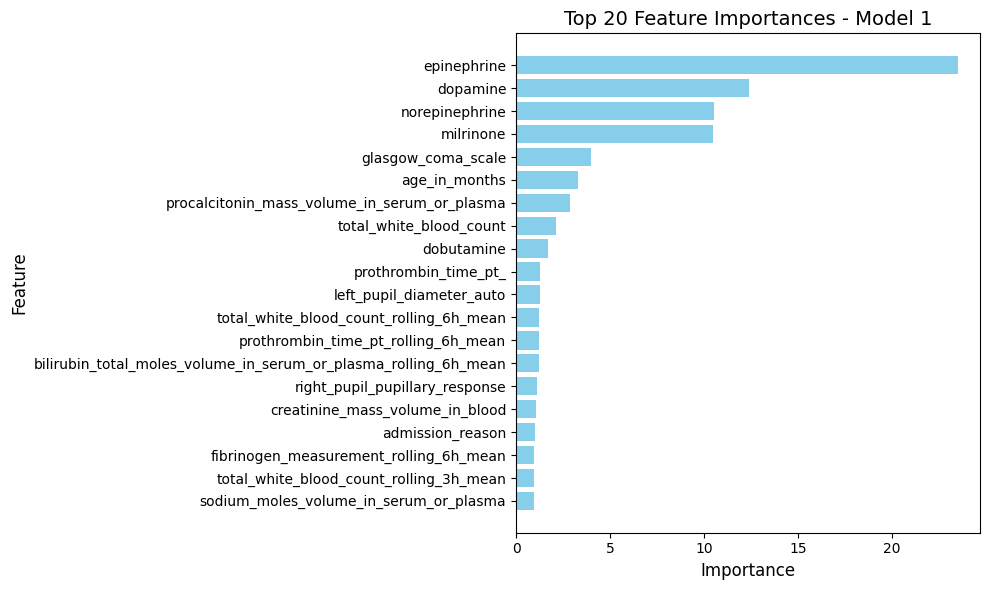

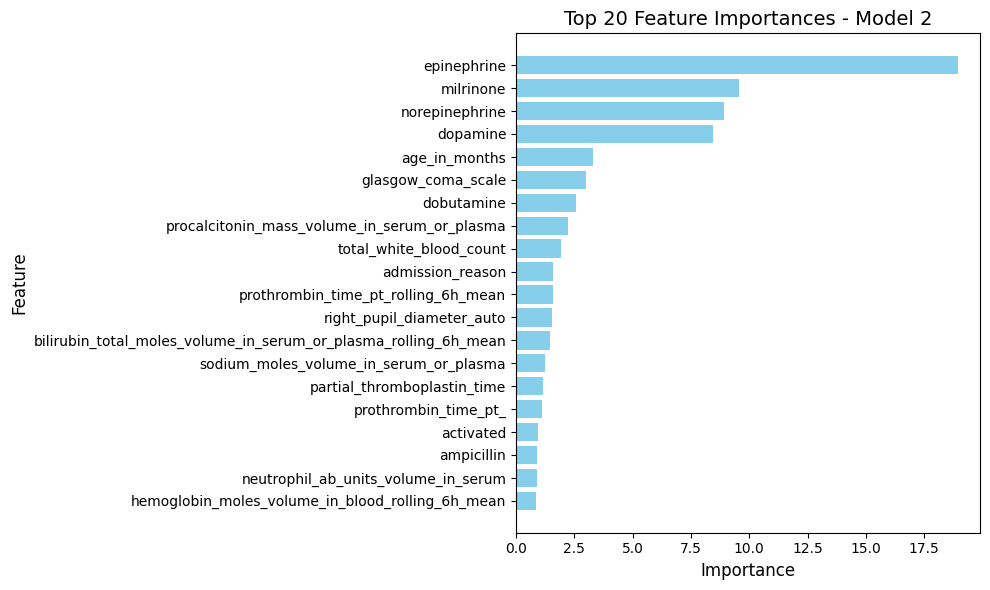

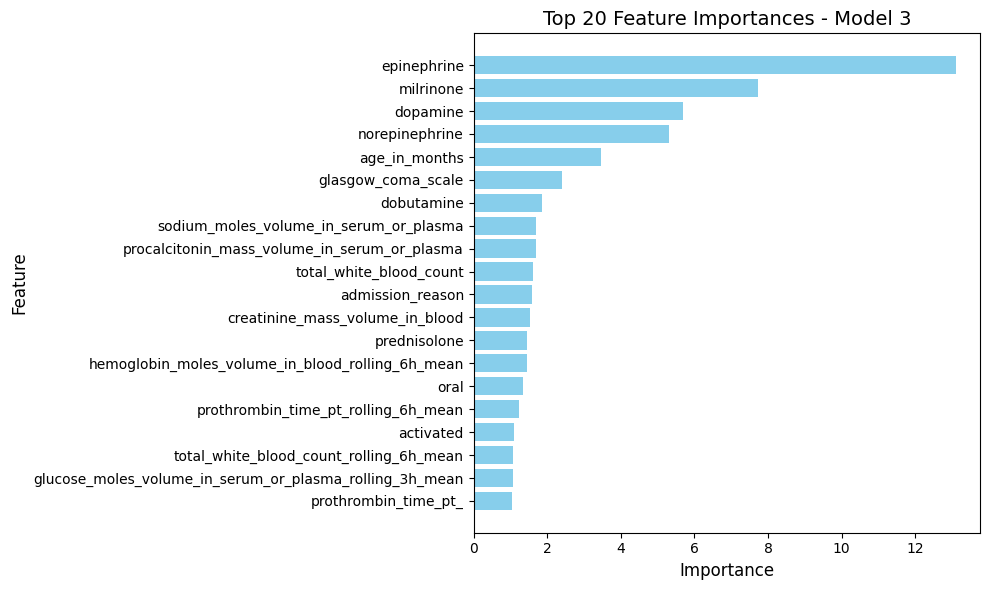

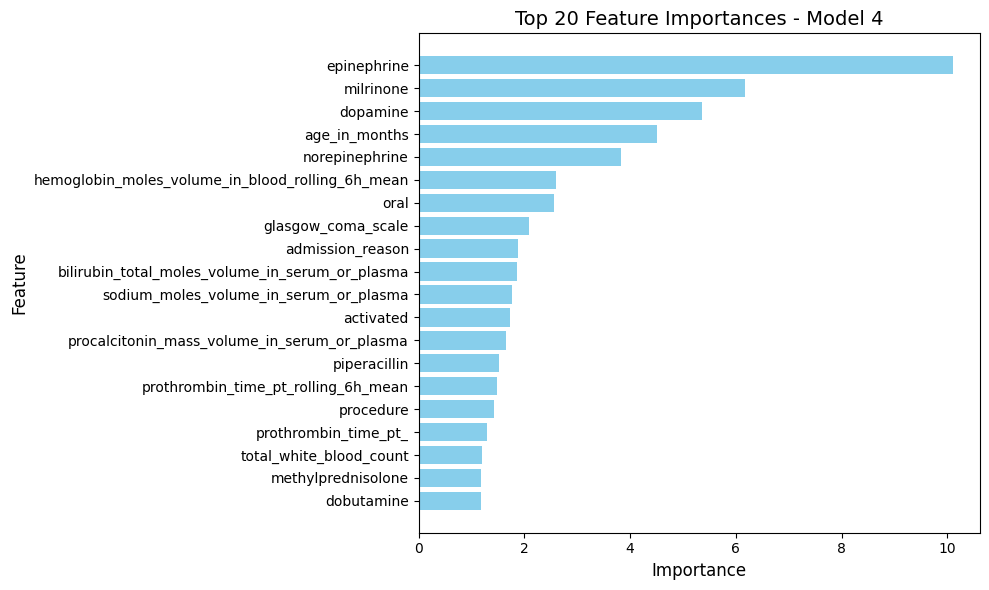

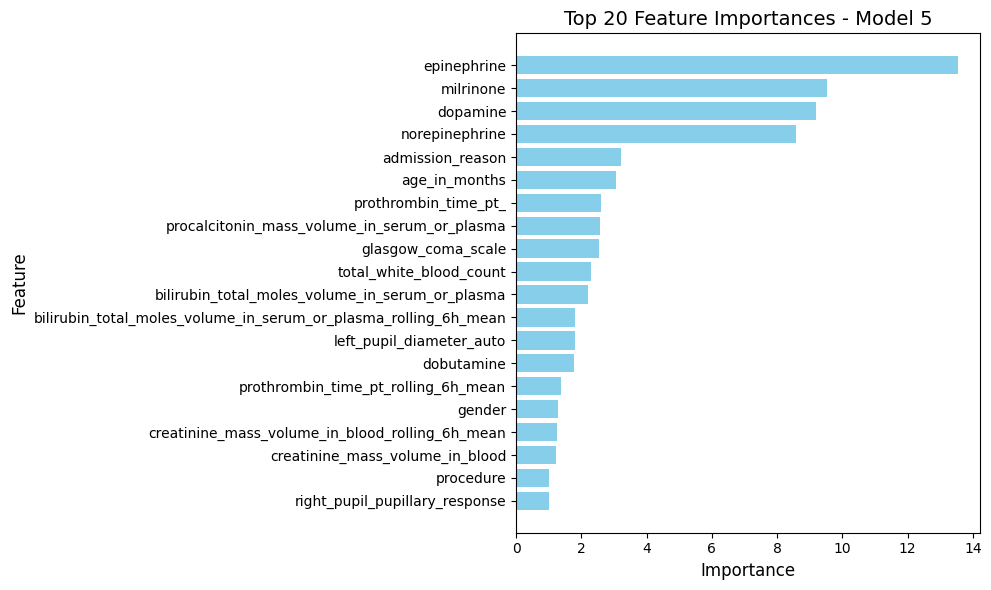

Best Features Across Models: {'right_pupil_pupillary_response', 'bilirubin_total_moles_volume_in_serum_or_plasma_rolling_6h_mean', 'bilirubin_total_moles_volume_in_serum_or_plasma', 'left_pupil_diameter_auto', 'total_white_blood_count_rolling_6h_mean', 'creatinine_mass_volume_in_blood', 'oral', 'gender', 'piperacillin', 'glucose_moles_volume_in_serum_or_plasma_rolling_3h_mean', 'epinephrine', 'total_white_blood_count_rolling_3h_mean', 'dobutamine', 'admission_reason', 'activated', 'prednisolone', 'creatinine_mass_volume_in_blood_rolling_6h_mean', 'total_white_blood_count', 'partial_thromboplastin_time', 'norepinephrine', 'prothrombin_time_pt_', 'age_in_months', 'sodium_moles_volume_in_serum_or_plasma', 'procedure', 'glasgow_coma_scale', 'procalcitonin_mass_volume_in_serum_or_plasma', 'neutrophil_ab_units_volume_in_serum', 'milrinone', 'right_pupil_diameter_auto', 'ampicillin', 'dopamine', 'prothrombin_time_pt_rolling_6h_mean', 'methylprednisolone', 'hemoglobin_moles_volume_in_blood_rol

In [468]:
feature_names = X_train.columns.tolist()
best_features = plot_feature_importance(cat_models, feature_names)

## Inference Catboost

In [469]:
test_df_valid = pd.read_csv("/kaggle/input/phems-dataset-outer/test_data_w_features_FINAL.csv")
test_df_valid.sample(5)

,measurement_datetime,base_excess_in_venous_blood_by_calculation,potassium_moles_volume_in_blood,bilirubin_total_moles_volume_in_serum_or_plasma,neutrophil_ab_units_volume_in_serum,hematocrit_volume_fraction_of_blood,glucose_moles_volume_in_serum_or_plasma,chloride_moles_volume_in_blood,sodium_moles_volume_in_serum_or_plasma,c_reactive_protein_mass_volume_in_serum_or_plasma,carbon_dioxide_partial_pressure_in_venous_blood,oxygen_partial_pressure_in_venous_blood,bicarbonate_moles_volume_in_venous_blood,prothrombin_time_pt_,procalcitonin_mass_volume_in_serum_or_plasma,lactate_moles_volume_in_blood,creatinine_mass_volume_in_blood,fibrinogen_measurement,partial_thromboplastin_time,activated,total_white_blood_count,platelet_count,white_blood_cell_count,blood_arterial_ph,hemoglobin_moles_volume_in_blood,body_temperature,left_pupil_diameter_auto,right_pupil_diameter_auto,glasgow_coma_scale,age_in_months,pulse,arterial_pulse_pressure,right_pupil_pupillary_response,left_pupil_pupillary_response,procedure,admission_reason,gender,drug_concept_id,route_concept_id,drug_str,route_str,amikacin,amoxicillin,ampicillin,anidulafungin,azithromycin,cefadroxil,cefazolin,cefepime,cefotaxime,ceftazidime,ceftolozane,cefuroxime,ciprofloxacin,clarithromycin,clindamycin,colistin,daptomycin,dexamethasone,dobutamine,dopamine,epinephrine,ertapenem,erythromycin,fluconazole,fosfomycin,fusidate,gentamicin,hydrocortisone,isavuconazole,isoproterenol,levofloxacin,levosimendan,linezolid,meropenem,methylprednisolone,micafungin,milrinone,mupirocin,nitrofurantoin,no_drug,norepinephrine,penicillin,phenylephrine,piperacillin,prednisolone,rifampin,teicoplanin,tobramycin,trimethoprim,vancomycin,voriconazole,intramuscula,intrapulmonary,intravenous,nasal,no_route,ophthalmic,oral,otic,rectal,topical,visit_occurrence_id,person_id,base_excess_in_venous_blood_by_calculation_rolling_3h_mean,potassium_moles_volume_in_blood_rolling_3h_mean,bilirubin_total_moles_volume_in_serum_or_plasma_rolling_3h_mean,neutrophil_ab_units_volume_in_serum_rolling_3h_mean,hematocrit_volume_fraction_of_blood_rolling_3h_mean,glucose_moles_volume_in_serum_or_plasma_rolling_3h_mean,chloride_moles_volume_in_blood_rolling_3h_mean,sodium_moles_volume_in_serum_or_plasma_rolling_3h_mean,c_reactive_protein_mass_volume_in_serum_or_plasma_rolling_3h_mean,carbon_dioxide_partial_pressure_in_venous_blood_rolling_3h_mean,oxygen_partial_pressure_in_venous_blood_rolling_3h_mean,bicarbonate_moles_volume_in_venous_blood_rolling_3h_mean,prothrombin_time_pt_rolling_3h_mean,procalcitonin_mass_volume_in_serum_or_plasma_rolling_3h_mean,lactate_moles_volume_in_blood_rolling_3h_mean,creatinine_mass_volume_in_blood_rolling_3h_mean,fibrinogen_measurement_rolling_3h_mean,partial_thromboplastin_time_rolling_3h_mean,total_white_blood_count_rolling_3h_mean,platelet_count_rolling_3h_mean,white_blood_cell_count_rolling_3h_mean,blood_arterial_ph_rolling_3h_mean,hemoglobin_moles_volume_in_blood_rolling_3h_mean,body_temperature_rolling_3h_mean,base_excess_in_venous_blood_by_calculation_rolling_6h_mean,potassium_moles_volume_in_blood_rolling_6h_mean,bilirubin_total_moles_volume_in_serum_or_plasma_rolling_6h_mean,neutrophil_ab_units_volume_in_serum_rolling_6h_mean,hematocrit_volume_fraction_of_blood_rolling_6h_mean,glucose_moles_volume_in_serum_or_plasma_rolling_6h_mean,chloride_moles_volume_in_blood_rolling_6h_mean,sodium_moles_volume_in_serum_or_plasma_rolling_6h_mean,c_reactive_protein_mass_volume_in_serum_or_plasma_rolling_6h_mean,carbon_dioxide_partial_pressure_in_venous_blood_rolling_6h_mean,oxygen_partial_pressure_in_venous_blood_rolling_6h_mean,bicarbonate_moles_volume_in_venous_blood_rolling_6h_mean,prothrombin_time_pt_rolling_6h_mean,procalcitonin_mass_volume_in_serum_or_plasma_rolling_6h_mean,lactate_moles_volume_in_blood_rolling_6h_mean,creatinine_mass_volume_in_blood_rolling_6h_mean,fibrinogen_measurement_rolling_6h_mean,partial_thromboplastin_time_rolling_6h_mean,total_white_blood_count_rolling_6h_mean,platelet_count_rolling

#### It should have 130483 rows, let's check that

In [470]:
calculate_nan_ratios(test_df_valid)

measurement_datetime                                0.000000
base_excess_in_venous_blood_by_calculation          0.137704
potassium_moles_volume_in_blood                     0.092786
bilirubin_total_moles_volume_in_serum_or_plasma     0.514465
neutrophil_ab_units_volume_in_serum                 0.121449
                                                      ...   
white_blood_cell_count_rolling_6h_mean              0.109348
blood_arterial_ph_rolling_6h_mean                   0.090816
hemoglobin_moles_volume_in_blood_rolling_6h_mean    0.098978
body_temperature_rolling_6h_mean                    0.072362
person_id_datetime                                  0.000000
Length: 153, dtype: float64

In [471]:
test_df_valid_gen = pd.read_csv("/kaggle/working/test_data_w_features_FINAL.csv")
test_df_valid_gen.sample(5)

,measurement_datetime,base_excess_in_venous_blood_by_calculation,potassium_moles_volume_in_blood,bilirubin_total_moles_volume_in_serum_or_plasma,neutrophil_ab_units_volume_in_serum,hematocrit_volume_fraction_of_blood,glucose_moles_volume_in_serum_or_plasma,chloride_moles_volume_in_blood,sodium_moles_volume_in_serum_or_plasma,c_reactive_protein_mass_volume_in_serum_or_plasma,carbon_dioxide_partial_pressure_in_venous_blood,oxygen_partial_pressure_in_venous_blood,bicarbonate_moles_volume_in_venous_blood,prothrombin_time_pt_,procalcitonin_mass_volume_in_serum_or_plasma,lactate_moles_volume_in_blood,creatinine_mass_volume_in_blood,fibrinogen_measurement,partial_thromboplastin_time,activated,total_white_blood_count,platelet_count,white_blood_cell_count,blood_arterial_ph,hemoglobin_moles_volume_in_blood,body_temperature,left_pupil_diameter_auto,right_pupil_diameter_auto,glasgow_coma_scale,pulse,arterial_pulse_pressure,right_pupil_pupillary_response,left_pupil_pupillary_response,procedure,admission_reason,visit_occurrence_id,person_id,drug_concept_id,route_concept_id,drug_str,route_str,amikacin,amoxicillin,ampicillin,anidulafungin,azithromycin,cefadroxil,cefazolin,cefepime,cefotaxime,ceftazidime,ceftolozane,cefuroxime,ciprofloxacin,clarithromycin,clindamycin,colistin,daptomycin,dexamethasone,dobutamine,dopamine,epinephrine,ertapenem,erythromycin,fluconazole,fosfomycin,fusidate,gentamicin,hydrocortisone,isavuconazole,isoproterenol,levofloxacin,levosimendan,linezolid,meropenem,methylprednisolone,micafungin,milrinone,mupirocin,nitrofurantoin,no_drug,norepinephrine,penicillin,phenylephrine,piperacillin,prednisolone,rifampin,teicoplanin,tobramycin,trimethoprim,vancomycin,voriconazole,intramuscula,intrapulmonary,intravenous,nasal,no_route,ophthalmic,oral,otic,rectal,topical,base_excess_in_venous_blood_by_calculation_rolling_3h_mean,potassium_moles_volume_in_blood_rolling_3h_mean,bilirubin_total_moles_volume_in_serum_or_plasma_rolling_3h_mean,neutrophil_ab_units_volume_in_serum_rolling_3h_mean,hematocrit_volume_fraction_of_blood_rolling_3h_mean,glucose_moles_volume_in_serum_or_plasma_rolling_3h_mean,chloride_moles_volume_in_blood_rolling_3h_mean,sodium_moles_volume_in_serum_or_plasma_rolling_3h_mean,c_reactive_protein_mass_volume_in_serum_or_plasma_rolling_3h_mean,carbon_dioxide_partial_pressure_in_venous_blood_rolling_3h_mean,oxygen_partial_pressure_in_venous_blood_rolling_3h_mean,bicarbonate_moles_volume_in_venous_blood_rolling_3h_mean,prothrombin_time_pt_rolling_3h_mean,procalcitonin_mass_volume_in_serum_or_plasma_rolling_3h_mean,lactate_moles_volume_in_blood_rolling_3h_mean,creatinine_mass_volume_in_blood_rolling_3h_mean,fibrinogen_measurement_rolling_3h_mean,partial_thromboplastin_time_rolling_3h_mean,total_white_blood_count_rolling_3h_mean,platelet_count_rolling_3h_mean,white_blood_cell_count_rolling_3h_mean,blood_arterial_ph_rolling_3h_mean,hemoglobin_moles_volume_in_blood_rolling_3h_mean,body_temperature_rolling_3h_mean,base_excess_in_venous_blood_by_calculation_rolling_6h_mean,potassium_moles_volume_in_blood_rolling_6h_mean,bilirubin_total_moles_volume_in_serum_or_plasma_rolling_6h_mean,neutrophil_ab_units_volume_in_serum_rolling_6h_mean,hematocrit_volume_fraction_of_blood_rolling_6h_mean,glucose_moles_volume_in_serum_or_plasma_rolling_6h_mean,chloride_moles_volume_in_blood_rolling_6h_mean,sodium_moles_volume_in_serum_or_plasma_rolling_6h_mean,c_reactive_protein_mass_volume_in_serum_or_plasma_rolling_6h_mean,carbon_dioxide_partial_pressure_in_venous_blood_rolling_6h_mean,oxygen_partial_pressure_in_venous_blood_rolling_6h_mean,bicarbonate_moles_volume_in_venous_blood_rolling_6h_mean,prothrombin_time_pt_rolling_6h_mean,procalcitonin_mass_volume_in_serum_or_plasma_rolling_6h_mean,lactate_moles_volume_in_blood_rolling_6h_mean,creatinine_mass_volume_in_blood_rolling_6h_mean,fibrinogen_measurement_rolling_6h_mean,partial_thromboplastin_time_rolling_6h_mean,total_white_blood_count_rolling_6h_mean,platelet_count_rolling_6h_mean,white_blood_

In [472]:
test_df_valid_gen.shape

(130483, 152)

In [473]:
test_df_valid.shape

(130483, 153)

In [474]:
# Prepare the test data
X_test = test_df_valid.drop(columns=["person_id_datetime" ,"drug_concept_id", "route_concept_id", "drug_str", "route_str", "person_id", "measurement_datetime", "visit_occurrence_id"])

# Ensure the categorical columns are the same as in training
X_test[categorical_features] = X_test[categorical_features].fillna("missing").astype(str)

In [475]:
# Initialize an empty list to store predictions from each model
ensemble_predictions = []

# Load each fold model and make predictions
for fold in range(1,6):
    print(f"Loading and predicting with model fold {fold}")
    
    # Load the model for the current fold
    model = CatBoostClassifier()
    model.load_model(f"catboost_fold_{fold}.cbm") # Models that were trained in two sub-sections before

    # Create the test pool
    test_pool = Pool(data=X_test, cat_features=categorical_features)

    # Predict probabilities for class 1 (Sepsis)
    y_pred = model.predict_proba(test_pool)[:, 1]  # Probability for positive class

    # Append predictions to the list
    ensemble_predictions.append(y_pred)

# Average the predictions across all models
y_pred = sum(ensemble_predictions) / len(ensemble_predictions)

# Format the predictions and person_id_datetime
test_df_valid['SepsisLabel'] = y_pred  # Add predictions to the test dataframe
test_df_valid['person_id_datetime'] = test_df_valid['person_id'].astype(str) + "_" + test_df_valid['measurement_datetime'].astype(str)


Loading and predicting with model fold 1
Loading and predicting with model fold 2
Loading and predicting with model fold 3
Loading and predicting with model fold 4
Loading and predicting with model fold 5


In [476]:
# Prepare the submission DataFrame
submission = test_df_valid[['person_id_datetime', 'SepsisLabel']]

# Drop duplicates
submission = submission.drop_duplicates(subset='person_id_datetime')

#### Let's check the hist of our predictions quickly!

array([[<Axes: title={'center': 'SepsisLabel'}>]], dtype=object)

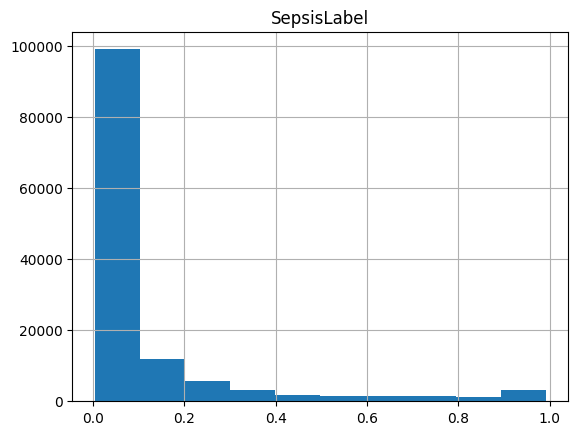

In [477]:
submission.hist()

In [478]:
assert submission['SepsisLabel'].isna().sum() == 0, "There are unmatched rows in submission!"

In [480]:
submission.to_csv("submission.csv", index=False)